# **Cluster-LLM per Real-Time Time-Series Anomaly Detection**

### *Giulia Simoncini*

### **Introduzione**

Il notebook realizzato implementa la pipeline sperimentale dell'articolo **Cluster-LLM: Adaptive Real-Time Time-Series Anomaly Detection Using LLMs**
(Zhu et al., CSIS-IAC 2025).

### **Dati Utilizzati**
I dati utilizzati per l'esecuzione degli esperimenti presenti nel notebook sono riportati nella cartella `data` e si tratta dei dataset **KPI (AIOps)** e **Yahoo S5 (Yahoo Labs)**.

**KPI** è un dataset fornito dalla competizione di dati AIOps, contenente molteplici serie temporali di indicatori chiave di prestazione (KPI) con le relative annotazioni sulle anomalie. Questi dati sono stati raccolti da varie aziende Internet, tra cui Sogou, Tencent ed eBay. La maggior parte delle curve KPI ha un intervallo di campionamento di 1 minuto, mentre alcune serie presentano un intervallo di 5 minuti.

**Yahoo** è un dataset aperto per il rilevamento delle anomalie rilasciato da Yahoo Labs. È composto sia da serie temporali reali che sintetiche, ciascuna etichettata con punti di anomalia. Il dataset è progettato per valutare l'accuratezza del rilevamento di diversi tipi di anomalie, come gli outlier puntuali e i punti di cambiamento (denominati change-points). Il sottoinsieme sintetico include serie con diversi trend, stagionalità e livelli di rumore, mentre il sottoinsieme reale contiene metriche dei servizi online di Yahoo, che riflettono comportamenti e anomalie del mondo reale.  

### **Pipeline Implementata**
La pipeline implementata nel presente notebook affronta le seguenti fasi: 
1. **Preprocessing** dei dati di serie storiche (che comprende la gestione valori mancanti, la mitigazione del rumore e l'arricchimento dei timestamp con informazioni temporali dettagliate);
2. **Clustering** (usando l'algoritmo K-means + indice Calinski-Harabasz per scegliere il valore del parametro k) sulle feature giornaliere (ovvero media/varianza in 3 finestre orarie);
3. **Inferenza delle baseline adattive** usando un LLM guidato da **Chain-of-Thought (CoT)** in 3 step:
   - Step 1: baseline via z-score giornaliero;
   - Step 2: baseline via fitting Gaussiano su finestre scorrevoli di ±5 minuti;
   - Step 3: fusione dei due risultati;
4. **Confidence score** per ciascun cluster (in base alla frequenza storica del pattern);
5. **Rilevamento delle anomalie in tempo reale** con scoring pesato dalla confidenza dei cluster (si tratta dell'Algoritmo di Real-Time Anomaly Detection dell'articolo di riferimento);
6. **Confronto** con baseline non supervisionate (ossia LOF, LSTM-VAE, DONUT, SR-CNN);
7. **Valutazione** sulle metriche di Precision, Recall, F1-score e Latenza di rilevamento, sui dataset **KPI** e **Yahoo S5**.

### **Nota sull'uso di LLM**
L'articolo di riferimento usa `deepseek-r1:8b` (via Ollama) per il prompting CoT. Il notebook realizzato, ad esclusione dell'appendice, **non effettua chiamate a un LLM esterno**, ma implementa direttamente, in modo deterministico, la stessa logica matematica descritta nei prompt del paper (z-score, fitting Gaussiano su finestra ±5 min, fusione). La pipeline illustrata rimane quindi eseguibile end-to-end senza dipendenze esterne (Ollama/GPU) e senza timeout di rete.

Nel presente notebook è dunque riportata, soltanto in appendice, l'implementazione usando il LLM per il prompting CoT come effettuato dall'articolo di riferimento, ma utilizzando soltanto due serie (una per KPI e una per Yahoo).

### **1. Setup e Import**

Inzialmente è necessario importare le librerie usate in tutto il notebook e fissare i seed casuali per rendere l'esecuzione riproducibile. Le librerie principali utilizzate sono `numpy` (libreria fondamentale per il calcolo numerico), `pandas` (libreria molto utilizzata per la gestione e l'analisi dei dati), `matplotlib` (libreria usata per la creazione di grafici) e `scikit-learn` per K-means/Calinski-Harabasz/LOF. Come ulteriori librerie o moduli sono usate anche `os` (che permette di interagire con il sistema operativo), `time` (che consente di lavorare con il tempo, per misurare ad esempio i tempi di esecuzione di procedure), `random` (che serve per generare numeri o scelte casuali), `warnings` (che serve per gestire gli avvisi (warning) prodotti da Python o dalle librerie), `dataclass` (che permette di creare facilmente classi utilizzate principalmente per contenere dati), `Dict` e `Tuple` (che provengono dal modulo standard typing e servono principalmente per indicare il tipo dei dati nelle annotazioni). Usando `matplotlib.rcParams` si importa lo stile di default dei grafici usato da tutte le figure successive.

In [1]:

import os, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Tuple
import matplotlib.dates as mdates
import math

from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings("ignore")
np.random.seed(48)
random.seed(48)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

### **2. Dataset Utilizzati**

Il presente notebook utilizza due dataset pubblici, che sono usati anche dall'articolo in questione. Tali dataset sono riportati nella cartella `data` e sono presentati nella seguente tabella:

| Dataset | Tipo | Entità | Punti totali | Punti anomali | Fonte |
|---|---|---|---|---|---|
| **KPI** (AIOps competition) | Reale | 29 | 5,922,913 | 134,114 (2.26%) | Paper (Table III) |
| **KPI** (AIOps competition) | Reale | 29 | 3,004,066 | 79,554 (2.65%) | Notebook (dati reali caricati) |
| **Yahoo** (S5, Yahoo Labs) | Reale/Sintetico | 367 | 572,966 | 3,896 (0.68%) | Paper (Table III) |
| **Yahoo** (S5, Yahoo Labs) | Reale/Sintetico | 67 | 94,866 | 1,669 (1.76%) | Notebook (dati reali caricati) |

Se si desidera eseguire il notebook usando i due dataset (ossia KPI e Yahoo), è necessario assicurarsi che essi siano già stati scaricati e che si trovino all'interno della cartella `data`. Il codice, infatti, dapprima prova a caricare i file se l'utente li ha già scaricati in `./data/kpi/` e `./data/yahoo/`; altrimenti, se i file non sono presenti, genera dati sintetici realistici aventi la stessa struttura statistica. 

I file presenti in KPI e in Yahoo sono in formato CSV e hanno colonne `timestamp, value, label, KPI ID` per KPI e `timestamp, value, is_anomaly` per Yahoo. I dati sintetici generati con la stessa struttura statistica, qualora KPI e Yahoo non siano presenti, riportano pattern giornalieri ciclici con l'aggiunta di rumore e di anomalie puntuali, iniettate con la stessa percentuale di anomalie del paper. L'obbiettivo è quello di poter eseguire l'intera pipeline end-to-end e verificarne la correttezza anche in assenza dei dataset KPI e Yahoo. È opportuno notare che basta sostituire i CSV reali per ottenere i risultati effettivi sui dataset scelti.

### **2.1 Caricamento dei Dati**

La cella sottostante definisce e invoca le funzioni di caricamento dei due dataset (KPI e Yahoo). Si tratta di:

- `try_load_real_kpi` che cerca i file reali del dataset **KPI** (AIOps competition), dando priorità a `phase2_train.csv` (che comprende 29 entità ed è coerente con la Table III del paper) rispetto a `train.csv` (che contiene solo 26 entità, risultando di fatto uno split parziale);
- `try_load_real_yahoo` che cerca ricorsivamente i file **Yahoo S5** (`real_*.csv`), sia in cartelle annidate sia posizionati direttamente nella cartella `data`;
- se nessun file reale è trovato, `generate_synthetic_series` produce dati sintetici aventi la stessa struttura statistica (pattern giornaliero ciclico che è costituito da 3 regimi: notte/mattina/pomeriggio-sera, rumore gaussiano, anomalie iniettate), per garantire che l'intera pipeline resti comunque eseguibile end-to-end.

Infine, `build_dataset` combina questi passi e restituisce un dizionario `{nome_entità: DataFrame}` per ciascun dataset.

In [2]:

KPI_DIR = "./data/kpi"
YAHOO_DIR = "./data/yahoo"

def try_load_real_kpi(kpi_dir=KPI_DIR):
    if not os.path.isdir(kpi_dir):
        return None
    found = {}
    for root, _, files in os.walk(kpi_dir):
        for f in files:
            fl = f.lower()
            if fl == "phase2_train.csv" and "phase2_train.csv" not in found:
                found["phase2_train.csv"] = os.path.join(root, f)
            elif fl == "train.csv" and "train.csv" not in found:
                found["train.csv"] = os.path.join(root, f)
    for name in ("phase2_train.csv", "train.csv"):
        if name in found:
            path = found[name]
            df = pd.read_csv(path)
            n_ent = df["KPI ID"].nunique() if "KPI ID" in df.columns else 1
            print(f"Caricato file KPI: {path} ({n_ent} entita').")
            return df
    return None

def try_load_real_yahoo(yahoo_dir=YAHOO_DIR):
    if not os.path.isdir(yahoo_dir):
        return None
    series = {}
    for root, _, files in os.walk(yahoo_dir):
        for f in sorted(files):
            if f.endswith(".csv"):
                path = os.path.join(root, f)
                try:
                    df = pd.read_csv(path)
                    cols_lower = set(c.lower() for c in df.columns)
                    if {"timestamp", "value"}.issubset(cols_lower):
                        series[f] = df
                except Exception as e:
                    print(f"  [WARN] impossibile leggere {path}: {e}")
    return series if series else None


def generate_synthetic_series(n_days=30, points_per_day=288, anomaly_rate=0.02,
                               start_ts=1606760000, freq_sec=300, seed=0):
    rng = np.random.RandomState(seed)
    n = n_days * points_per_day
    t = np.arange(n)
    timestamps = start_ts * 1000 + t * freq_sec * 1000  # ms epoch

    day_idx = t // points_per_day
    minute_of_day = (t % points_per_day) * (1440 // points_per_day)

    pattern_a = 0.5 + 0.4 * np.sin(2 * np.pi * minute_of_day / 1440) ** 2
    pattern_b = 0.2 + 0.15 * np.cos(2 * np.pi * minute_of_day / 1440) ** 2 + 0.1 * rng.rand(n)
    use_pattern_a = (day_idx % 3 != 0)

    base = np.where(use_pattern_a, pattern_a, pattern_b)
    noise = rng.normal(0, 0.03, size=n)
    values = np.clip(base + noise, 0, None)

    labels = np.zeros(n, dtype=int)
    n_anom = int(n * anomaly_rate)
    anom_idx = rng.choice(n, size=n_anom, replace=False)
    spike = rng.uniform(0.8, 2.0, size=n_anom)
    values[anom_idx] += spike
    labels[anom_idx] = 1

    missing_idx = rng.choice(n, size=int(0.005 * n), replace=False)
    values[missing_idx] = np.nan

    df = pd.DataFrame({"timestamp": timestamps, "value": values, "label": labels})
    return df


def build_dataset(name="KPI", max_entities=None):
    if name == "KPI":
        real = try_load_real_kpi()
        if real is not None:
            real = real.rename(columns=str.lower)
            id_col = next((c for c in real.columns if c.replace("_", " ").strip() == "kpi id"), None)
            if id_col is None:
                print("Caricato KPI reale da disco (singola entita').")
                return {"kpi_0": real}
            print(f"Caricato KPI reale da disco -> split per entita' sulla colonna '{id_col}'.")
            entities = list(real[id_col].unique())
            if max_entities is not None:
                entities = entities[:max_entities]
            out = {}
            for eid in entities:
                sub = real[real[id_col] == eid].drop(columns=[id_col]).reset_index(drop=True)
                out[f"kpi_{eid}"] = sub
            return out
        print("File KPI reali non trovati in ./data/kpi -> uso dati sintetici con struttura equivalente.")
        return {f"kpi_synth_{i}": generate_synthetic_series(
                    n_days=20, points_per_day=1440, anomaly_rate=0.0226, seed=100 + i)
                for i in range(3)}
    elif name == "Yahoo":
        real = try_load_real_yahoo()
        if real is not None:
            print("Caricato Yahoo reale da disco.")
            out = {}
            for k, df in real.items():
                df = df.rename(columns=str.lower)
                if "is_anomaly" in df.columns:
                    df = df.rename(columns={"is_anomaly": "label"})
                out[k] = df
            return out
        print("File Yahoo reali non trovati in ./data/yahoo -> uso dati sintetici con struttura equivalente.")
        return {f"yahoo_synth_{i}": generate_synthetic_series(
                    n_days=60, points_per_day=24, anomaly_rate=0.0068, freq_sec=3600, seed=200 + i)
                for i in range(5)}
    else:
        raise ValueError(name)

# Il dataset KPI reale contiene 29 entità distinte (Table III del paper).
# max_entities=None fa sì che vengano usate tutte le 29 entità, come nel paper 
# é possibile impostare un numero più piccolo solo per test/debug rapidi, tenendo conto 
# però che le metriche aggregate finali si discosteranno dalla Table IV se non vengono usate tutte le entità.

KPI_MAX_ENTITIES = None  # None = usa tutte le entità disponibili (come nel paper di riferimento)
kpi_data = build_dataset("KPI", max_entities=KPI_MAX_ENTITIES)
yahoo_data = build_dataset("Yahoo")
print({k: v.shape for k, v in kpi_data.items()})
print({k: v.shape for k, v in yahoo_data.items()})

Caricato file KPI: ./data/kpi/Finals_dataset/phase2_train.csv (29 entita').
Caricato KPI reale da disco -> split per entita' sulla colonna 'kpi id'.
Caricato Yahoo reale da disco.
{'kpi_da10a69f-d836-3baa-ad40-3e548ecf1fbd': (107717, 3), 'kpi_e0747cad-8dc8-38a9-a9ab-855b61f5551d': (8784, 3), 'kpi_ab216663-dcc2-3a24-b1ee-2c3e550e06c9': (11138, 3), 'kpi_54350a12-7a9d-3ca8-b81f-f886b9d156fd': (8866, 3), 'kpi_a8c06b47-cc41-3738-9110-12df0ee4c721': (8863, 3), 'kpi_0efb375b-b902-3661-ab23-9a0bb799f4e3': (8784, 3), 'kpi_c02607e8-7399-3dde-9d28-8a8da5e5d251': (8784, 3), 'kpi_301c70d8-1630-35ac-8f96-bc1b6f4359ea': (8784, 3), 'kpi_7103fa0f-cac4-314f-addc-866190247439': (128992, 3), 'kpi_4d2af31a-9916-3d9f-8a8e-8a268a48c095': (128872, 3), 'kpi_6a757df4-95e5-3357-8406-165e2bd49360': (129010, 3), 'kpi_ffb82d38-5f00-37db-abc0-5d2e4e4cb6aa': (128784, 3), 'kpi_57051487-3a40-3828-9084-a12f7f23ee38': (128787, 3), 'kpi_f0932edd-6400-3e63-9559-0a9860a1baa9': (128789, 3), 'kpi_431a8542-c468-3988-a508-3afd0

Il dizionario stampato in fondo mostra, per ogni entità, il numero di righe disponibili. Nel caso del dataset KPI, tale valore varia da un minimo di ~8.800 punti a un massimo di ~146.000; la forte eterogeneità di lunghezza tra le serie è tipica di tale dataset AIOps reale e verrà gestita in modo scalabile nelle sezioni successive (ad esempio tramite subsampling nei modelli di confronto).

### **2.2 Exploratory Data Analysis (EDA) dei Dataset KPI e Yahoo**

Prima di attuare le fasi di preprocessing e di clustering dei dati, è necessario effettuare una EDA per ottenere informazioni sui dataset in esame, ovvero per capire quante entità (ovvero serie) compongono ciascun dataset, quanti sono i punti totali e soprattutto quale è la *percentuale di anomalie* presente.

La funzione `eda_summary` costruisce, per ciascuna entità di un dataset, una riga avente numero di punti, numero e percentuale di anomalie, range dei valori e valori mancanti; stampa poi le statistiche aggregate dell'intero dataset in modo da poterle confrontare con quelle riportate nella Table III del paper di riferimento.

L'obiettivo è quello di verificare, prima di procedere con clustering e detection, che i dati caricati abbiano una distribuzione delle anomalie coerente con quella attesa.

In [3]:

def eda_summary(data_dict: Dict[str, pd.DataFrame], dataset_name: str) -> pd.DataFrame:
    # tabella EDA per entità (che riporta n. punti, n. anomalie, % anomalie, range valori)
    rows = []
    for key, df in data_dict.items():
        n = len(df)
        n_anom = int(df["label"].fillna(0).sum()) if "label" in df.columns else 0
        rows.append({
            "entita'": key,
            "n_punti": n,
            "n_anomalie": n_anom,
            "%_anomalie": 100 * n_anom / n if n else 0.0,
            "valore_min": df["value"].min(),
            "valore_max": df["value"].max(),
            "valori_mancanti": int(df["value"].isna().sum()),
        })
    summary = pd.DataFrame(rows).sort_values("%_anomalie", ascending=False).reset_index(drop=True)

    tot_points = summary["n_punti"].sum()
    tot_anom = summary["n_anomalie"].sum()
    print(f"EDA - {dataset_name}")
    print(f"Entita' (serie): {len(summary)}")
    print(f"Punti totali: {tot_points:,}")
    print(f"Punti anomali totali: {tot_anom:,}  ({100 * tot_anom / tot_points:.2f}% del dataset)")
    print(f"Valori mancanti totali: {summary['valori_mancanti'].sum():,}")
    print()
    return summary

kpi_eda = eda_summary(kpi_data, "KPI")
yahoo_eda = eda_summary(yahoo_data, "Yahoo")

print("Top 5 entita' KPI per percentuale di anomalie:")
display(kpi_eda.head())
print("Top 5 entita' Yahoo per percentuale di anomalie:")
display(yahoo_eda.head())

EDA - KPI
Entita' (serie): 29
Punti totali: 3,004,066
Punti anomali totali: 79,554  (2.65% del dataset)
Valori mancanti totali: 0

EDA - Yahoo
Entita' (serie): 67
Punti totali: 94,866
Punti anomali totali: 1,669  (1.76% del dataset)
Valori mancanti totali: 0

Top 5 entita' KPI per percentuale di anomalie:


,entita',n_punti,n_anomalie,%_anomalie,valore_min,valore_max,valori_mancanti
0,kpi_da10a69f-d836-3baa-ad40-3e548ecf1fbd,107717,7363,6.835504,0.0000,0.474405,0
1,kpi_431a8542-c468-3988-a508-3afd06a218da,129046,8222,6.371371,0.0000,15.000000,0
2,kpi_4d2af31a-9916-3d9f-8a8e-8a268a48c095,128872,7396,5.739028,0.0000,38.250000,0
3,kpi_9c639a46-34c8-39bc-aaf0-9144b37adfc8,108074,6095,5.639654,0.0000,138.750000,0
4,kpi_f0932edd-6400-3e63-9559-0a9860a1baa9,128789,7254,5.632469,0.0625,518.799988,0


Top 5 entita' Yahoo per percentuale di anomalie:


,entita',n_punti,n_anomalie,%_anomalie,valore_min,valore_max,valori_mancanti
0,real_19.csv,1424,227,15.941011,0.0,452.0,0
1,real_17.csv,1424,227,15.941011,0.0,14353.0,0
2,real_46.csv,1441,109,7.564192,0.0,1858.0,0
3,real_28.csv,1441,82,5.690493,5.0,36854.0,0
4,real_40.csv,1427,80,5.606167,0.0,966.0,0


Per quanto riguarda il dataset **KPI** risultano 29 entità, 3.004.066 punti totali e un 2,65% di anomalie complessive (valore molto vicino al 2,26% riportato nella Table III del
paper). 

Per quanto riguarda il dataset **Yahoo** risultano 67 entità, 94.866 punti e un 1,76% di anomalie (anch'esso valore dello stesso ordine di grandezza di 0,68% riportato dal paper anche se leggermente più alto). 

Non si ha alcun valore mancante residuo; ciò significa che l'interpolazione applicata più avanti nel preprocessing non dovrà colmare grandi mancanze di dati. Le tabelle "Top 5 per percentuale di anomalie" mostrano le entità più critiche per ciascun dataset, ovvero le serie più difficili da modellare e per questo ottime per testare il metodo. Nel caso del dataset Yahoo, le entità più critiche sono `real_17.csv` e `real_19.csv`, aventi ~16% di anomalie.

### **2.3 Visualizzazione EDA**

Il codice sottostante produce due grafici affiancati: a sinistra è riportato un confronto a barre tra la percentuale di anomalie riportata nel paper (Table III) e quella effettivamente misurata sui dati qui caricati, sia per KPI che Yahoo; a destra è invece riportato un istogramma della percentuale di anomalie per singola entità, per entrambi i dataset allo scopo di visualizzare quanto è eterogenea la difficoltà delle serie all'interno di ciascun dataset.

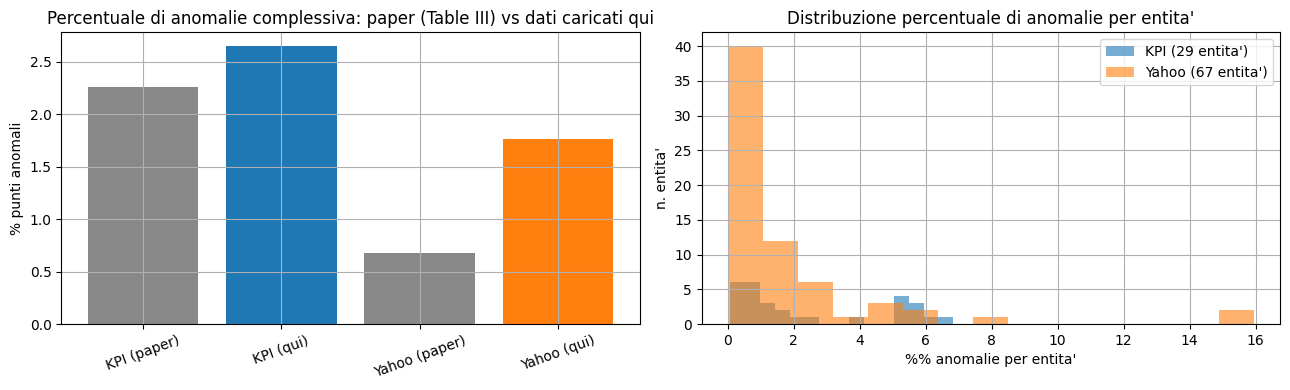

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(["KPI (paper)", "KPI (qui)", "Yahoo (paper)", "Yahoo (qui)"],
            [2.26,
             100 * kpi_eda["n_anomalie"].sum() / kpi_eda["n_punti"].sum(),
             0.68,
             100 * yahoo_eda["n_anomalie"].sum() / yahoo_eda["n_punti"].sum()],
            color=["#888888", "#1f77b4", "#888888", "#ff7f0e"])
axes[0].set_ylabel("% punti anomali")
axes[0].set_title("Percentuale di anomalie complessiva: paper (Table III) vs dati caricati qui")
axes[0].tick_params(axis="x", rotation=20)

axes[1].hist(kpi_eda["%_anomalie"], bins=15, alpha=0.6, label=f"KPI ({len(kpi_eda)} entita')")
axes[1].hist(yahoo_eda["%_anomalie"], bins=15, alpha=0.6, label=f"Yahoo ({len(yahoo_eda)} entita')")
axes[1].set_xlabel("%% anomalie per entita'")
axes[1].set_ylabel("n. entita'")
axes[1].set_title("Distribuzione percentuale di anomalie per entita'")
axes[1].legend()

plt.tight_layout()
plt.show()

Nel pannello di sinistra le barre con indicato "qui" (in blu per KPI e in arancione per Yahoo) risultano leggermente più alte di quelle grigie relative al paper di riferimento. Questo costituisce una conferma visiva della coerenza notata sopra (ossia 2,65% vs 2,26% su KPI, 1,76% vs 0,68% su Yahoo). Nel pannello di destra l'istogramma mostra che la maggior parte delle entità di entrambi i dataset si concentra su percentuali di anomalie basse (sotto il 5%), con una coda lunga di poche entità molto più anomale (fino al 15-16% su Yahoo); questa asimmetria è tipica dei benchmark di anomaly detection ed è il motivo per cui le metriche aggregate sono calcolate sull'insieme totale dei punti e non come media semplice tra le entità.

### **3. Data Preprocessing**

Questa sezione si concentra sull'imputazione/rimozione dei valori mancanti, sullo smoothing per ridurre il rumore e sull'arricchimento del timestamp con informazioni temporali dettagliate quali `year, month, day, hour, minute`.

### **3.1 Attuazione del Data Preprocessing**

La cella sottostante implementa il preprocessing appena descritto, tramite:
- `_infer_timestamp_unit` che rileva automaticamente se la colonna `timestamp` è in secondi/millisecondi epoch oppure un indice sequenziale orario (caso di Yahoo S5), gestendo anche i casi degeneri (ossia timestamp costanti o non numerici);
- `preprocess_series` che ordina cronologicamente i dati, interpola i valori mancanti, applica uno smoothing leggero e arricchisce ogni riga con anno/mese/giorno/ora/minuto, stampando per ciascuna entità una riga di diagnostica (`ts_unit`, righe scartate, giorni risultanti) per rendere subito visibile qualunque anomalia nella conversione dei timestamp.

I dataset considerati utilizzano convenzioni differenti per la rappresentazione temporale. In particolare, il dataset reale KPI (AIOps Competition) utilizza timestamp espressi in secondi, mentre i dati sintetici generati in questo notebook utilizzano timestamp espressi in millisecondi. Il dataset Yahoo S5 (A1Benchmark, file reali "real_*.csv"), invece, adotta una convenzione differente secondo cui la colonna timestamp non contiene un timestamp Unix, ma un indice sequenziale orario (1, 2, 3, ..., n).

Per garantire la robustezza dell'elaborazione rispetto a queste diverse convenzioni, la funzione `_infer_timestamp_unit` gestisce esplicitamente anche i casi degeneri, quali timestamp non numerici, valori NaN oppure intervalli temporali nulli o costanti. In tali situazioni viene restituito un esito dedicato ("invalid" o "constant"), evitando che l'anomalia venga propagata silenziosamente fino alla fase di bucketing giornaliero. In particolare, un intervallo temporale costante, se non intercettato preventivamente, potrebbe causare il collasso di tutti i campioni in un unico giorno, rendendo il problema più difficile da individuare e diagnosticare.

In [5]:

def _infer_timestamp_unit(ts: pd.Series) -> str:    
    ts_num = pd.to_numeric(ts, errors="coerce").dropna()
    if len(ts_num) == 0:
        return "invalid"
    max_ts = float(ts_num.max())
    min_ts = float(ts_num.min())
    n = len(ts_num)
    if max_ts == min_ts:
        return "constant"  # tutti i timestamp identici: nessuna struttura temporale ricavabile
    if max_ts > 1e12:
        return "ms"
    if (max_ts - min_ts) < 3 * n:
        return "index_hourly"
    return "s"


def preprocess_series(df: pd.DataFrame, smooth_window: int = 3, verbose: bool = False) -> pd.DataFrame:
    df = df.copy()

    # Per garantire robustezza si forza il timestamp a numerico e si scartano le righe non valide invece di
    # lasciare che NaN/stringhe si propaghino silenziosamente nel sort/groupby successivo.
    n_before = len(df)
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    n_dropped = n_before - len(df)

    # Si effettua l'imputazione dei valori mancanti (interpolazione lineare)
    df["value"] = df["value"].interpolate(method="linear", limit_direction="both")

    # Si attua uno smoothing leggero per ridurre il rumore (rolling mean centrata)
    df["value_smooth"] = df["value"].rolling(window=smooth_window, center=True, min_periods=1).mean()

    # Si arricchisce il timestamp
    ts_unit = _infer_timestamp_unit(df["timestamp"])
    if ts_unit == "index_hourly":
        row_position = np.arange(len(df))
        synthetic_seconds = pd.Series(row_position * 3600 + 1_600_000_000)
        dt = pd.to_datetime(synthetic_seconds, unit="s")
    elif ts_unit in ("constant", "invalid"):
        print(f"  [WARN] timestamp '{ts_unit}' per una serie di {len(df)} righe: "
              f"uso un indice posizionale orario di fallback. Controllare i dati grezzi.")
        synthetic_seconds = np.arange(len(df)) * 3600 + 1_600_000_000
        dt = pd.to_datetime(synthetic_seconds, unit="s")
    else:
        dt = pd.to_datetime(df["timestamp"], unit=ts_unit)
    df["year"] = dt.dt.year
    df["month"] = dt.dt.month
    df["day"] = dt.dt.day
    df["hour"] = dt.dt.hour
    df["minute"] = dt.dt.minute
    df["date"] = dt.dt.date
    df["minute_of_day"] = df["hour"] * 60 + df["minute"]

    if verbose:
        raw = df["timestamp"]
        print(f"  ts_unit={ts_unit:<13} n_righe={len(df):>8} (scartate={n_dropped:>4})  "
              f"ts_raw_min={raw.min():.0f}  ts_raw_max={raw.max():.0f}  "
              f"giorni_risultanti={df['date'].nunique()}")
    return df

print("Preprocessing KPI")
kpi_pp = {k: preprocess_series(v, verbose=True) for k, v in kpi_data.items()}
print("Preprocessing Yahoo")
yahoo_pp = {k: preprocess_series(v, verbose=True) for k, v in yahoo_data.items()}


def pick_example_key(pp_dict, min_days: int = 5) -> str:
    
    # Sceglie come serie d'esempio (per i grafici delle Sezioni successive) quella con più
    # giorni distinti e, a parità, con più anomalie vere (si tratta dei grafici più rappresentativi),
    # invece di prendere sempre la prima chiave del dizionario.

    # Per garantire robustezza se esiste almeno una serie con >= min_days giorni distinti, 
    # la selezione avviene SOLO tra quelle (ovvero si evita di scegliere una serie degenere con 
    # 1-2 giorni, che produrrebbe un solo cluster banale e pertanto grafici poco informativi). 
    
    # Se NESSUNA serie raggiunge min_days, si ripiega sul comportamento precedente ma si stampa
    # un avviso esplicito, così che il problema sia visibile invece di passare inosservato.
    
    def score(df):
        return (df["date"].nunique(), int(df["label"].fillna(0).sum()))

    candidates = [k for k in pp_dict if pp_dict[k]["date"].nunique() >= min_days]
    if not candidates:
        print(f"  [WARN] nessuna serie ha >= {min_days} giorni distinti: "
              f"tutte le serie sembrano degeneri (controllare i timestamp grezzi sopra). "
              f"Si procede comunque scegliendo la migliore disponibile.")
        candidates = list(pp_dict.keys())
    return max(candidates, key=lambda k: score(pp_dict[k]))

example_key = pick_example_key(kpi_pp)
yahoo_example_key = pick_example_key(yahoo_pp)
print("Esempio KPI:", example_key, "-> giorni:", kpi_pp[example_key]["date"].nunique(),
      "anomalie vere:", int(kpi_pp[example_key]["label"].fillna(0).sum()))
print("Esempio Yahoo:", yahoo_example_key, "-> giorni:", yahoo_pp[yahoo_example_key]["date"].nunique(),
      "anomalie vere:", int(yahoo_pp[yahoo_example_key]["label"].fillna(0).sum()))
kpi_pp[example_key].head()

Preprocessing KPI
  ts_unit=s             n_righe=  107717 (scartate=   0)  ts_raw_min=1476460800  ts_raw_max=1482940740  giorni_risultanti=76
  ts_unit=s             n_righe=    8784 (scartate=   0)  ts_raw_min=1469376000  ts_raw_max=1472010900  giorni_risultanti=32
  ts_unit=s             n_righe=   11138 (scartate=   0)  ts_raw_min=1467302400  ts_raw_max=1471044600  giorni_risultanti=43
  ts_unit=s             n_righe=    8866 (scartate=   0)  ts_raw_min=1469203200  ts_raw_max=1471881300  giorni_risultanti=32
  ts_unit=s             n_righe=    8863 (scartate=   0)  ts_raw_min=1469203200  ts_raw_max=1471881300  giorni_risultanti=32
  ts_unit=s             n_righe=    8784 (scartate=   0)  ts_raw_min=1472918400  ts_raw_max=1475553300  giorni_risultanti=32
  ts_unit=s             n_righe=    8784 (scartate=   0)  ts_raw_min=1469894400  ts_raw_max=1472529300  giorni_risultanti=32
  ts_unit=s             n_righe=    8784 (scartate=   0)  ts_raw_min=1474646400  ts_raw_max=1477281300  gio

,timestamp,value,label,value_smooth,year,month,day,hour,minute,date,minute_of_day
0,1491041280,181.14,0,177.265000,2017,4,1,10,8,2017-04-01,608
1,1491041340,173.39,0,178.240000,2017,4,1,10,9,2017-04-01,609
2,1491041400,180.19,0,180.003333,2017,4,1,10,10,2017-04-01,610
3,1491041460,186.43,0,182.726667,2017,4,1,10,11,2017-04-01,611
4,1491041520,181.56,0,182.156667,2017,4,1,10,12,2017-04-01,612


Nel caso delle 29 entità KPI, il timestamp è stato correttamente riconosciuto come epoch in secondi (`ts_unit=s`), con zero righe scartate e un numero di giorni risultanti sempre coerente con la durata attesa della serie (da 32 a 105 giorni a seconda dell'entità). 

Nel caso di Yahoo viene invece rilevato `ts_unit=index_hourly`, il caso critico discusso in precedenza: la colonna `timestamp` è un indice sequenziale (1, 2, 3, ...) e non un vero epoch, quindi viene ricostruito un asse orario sintetico basato sulla posizione di riga. L'anteprima del DataFrame (`kpi_pp[example_key].head()`) conferma che le nuove colonne `date` e `minute_of_day` sono popolate correttamente (ad esempio `2017-04-01`, minuto 608 = le 10:08).

### **3.2 Controllo Diagnostico Anti-regressione (bucketing giornaliero Yahoo)**

La cella seguente verifica, per **tutte** le serie Yahoo (non solo quella scelta come esempio per i plot), che il numero di date distinte non sia collassato in modo sospetto rispetto al numero di punti orari disponibili. Lo scopo è quello di intercettare subito eventuali regressioni nella conversione *timestamp $\rightarrow$ data*, prima che si ripercuotano silenziosamente sulla successiva fase di clustering e di instaurazione della baseline.

La logica implementata nella seguente cella è progettata per eseguire un controllo di sicurezza, indipendentemente dalla serie scelta come caso di esempio. Dapprima viene calcolato, per **tutte** le serie Yahoo, il numero di giorni distinti risultanti dal preprocessing e vengono segnalate come serie sospette quelle aventi una sola data ma più di 48 punti orari (che rappresenta il sintomo del bug di collasso temporale descritto nella sezione precedente). L'obbiettivo è quello di intercettare subito un'eventuale regressione futura nella logica di `_infer_timestamp_unit`, invece di scoprirla implicitamente nelle sezioni successive mediante grafici poco rappresentativi.

In [6]:
yahoo_days_check = {k: df["date"].nunique() for k, df in yahoo_pp.items()}
n_points_check = {k: len(df) for k, df in yahoo_pp.items()}

suspicious = {k: d for k, d in yahoo_days_check.items()
              if d <= 1 and n_points_check[k] > 48}  # >2 giorni di dati orari ma 1 sola data -> sospetto

print(f"Yahoo: {len(yahoo_days_check)} serie, giorni distinti per serie -> "
      f"min={min(yahoo_days_check.values())}, max={max(yahoo_days_check.values())}, "
      f"media={np.mean(list(yahoo_days_check.values())):.1f}")

if suspicious:
    print(f"\n  ATTENZIONE: {len(suspicious)} serie Yahoo con date collassate (possibile bug "
          f"nella conversione timestamp): {list(suspicious.keys())[:10]}")
else:
    print("OK: nessuna serie Yahoo presenta un collasso sospetto delle date.")

print(f"\nSerie scelta come esempio Yahoo: {yahoo_example_key} "
      f"-> giorni distinti: {yahoo_days_check[yahoo_example_key]}, "
      f"punti: {n_points_check[yahoo_example_key]}")

Yahoo: 67 serie, giorni distinti per serie -> min=32, max=62, media=59.9
OK: nessuna serie Yahoo presenta un collasso sospetto delle date.

Serie scelta come esempio Yahoo: real_53.csv -> giorni distinti: 62, punti: 1461


Se è caricato Yahoo, su tutte le 67 serie, il numero di giorni distinti varia tra un minimo di 32 e un massimo di 62 (media 59,9): nessuna serie risulta collassata a un solo
giorno, per cui il messaggio finale risulta essere "OK: nessuna serie Yahoo presenta un collasso sospetto delle date". La serie scelta come esempio per i grafici successivi è
`real_53.csv` (che presenta 62 giorni distinti e 1.461 punti), che è stata selezionata in quanto è quelle che è tra le più ricche di struttura temporale disponibile.

### **4. Time-Series Clustering**

Per ogni giorno, vengono calcolate media e deviazione standard su 3 finestre orarie: **[00:00-08:00], [08:00-16:00], [16:00-24:00]**, viene poi scelto il numero ottimale di cluster `k` tramite l'**indice Calinski-Harabasz**, per poi applicare l'algoritmo **K-means**.

La funzione `extract_daily_features` costruisce, per ogni giorno di una serie, il vettore di feature (media e deviazione standard del valore in tre finestre orarie: 0-8h, 8-16h, 16-24h); la funzione `choose_best_k` applica K-means per diversi valori di k e seleziona quello che massimizza l'indice **Calinski-Harabasz**; la funzione `cluster_series` mette insieme i due passi e assegna un'etichetta di cluster a ogni giorno (e quindi a ogni punto) della serie d'esempio.

In [7]:

WINDOWS = [(0, 480), (480, 960), (960, 1440)]  # minuti: 0-8h, 8-16h, 16-24h

def extract_daily_features(df: pd.DataFrame) -> pd.DataFrame:
    # Costruisce la matrice delle features, che presenta una riga per giorno, [avg_w1, std_w1, avg_w2, std_w2, avg_w3, std_w3]
    rows = []
    for date, g in df.groupby("date"):
        feats = {"date": date}
        for i, (lo, hi) in enumerate(WINDOWS, start=1):
            sub = g[(g["minute_of_day"] >= lo) & (g["minute_of_day"] < hi)]["value_smooth"]
            feats[f"avg_{i}"] = sub.mean() if len(sub) else 0.0
            feats[f"std_{i}"] = sub.std() if len(sub) > 1 else 0.0
        rows.append(feats)
    feat_df = pd.DataFrame(rows).fillna(0.0)
    return feat_df


def choose_best_k(X: np.ndarray, k_min=2, k_max=6, seed=42) -> Tuple[int, KMeans]:
    # Sceglie k massimizzando l'indice Calinski-Harabasz
    best_k, best_score, best_model = k_min, -np.inf, None
    k_max = min(k_max, max(2, len(X) - 1))
    for k in range(k_min, k_max + 1):
        if k >= len(X):
            break
        km = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(X)
        if len(set(km.labels_)) < 2:
            continue
        score = calinski_harabasz_score(X, km.labels_)
        if score > best_score:
            best_k, best_score, best_model = k, score, km
    if best_model is None:  # fallback se troppo pochi giorni
        best_model = KMeans(n_clusters=min(2, len(X)), random_state=seed, n_init=10).fit(X)
        best_k = best_model.n_clusters
    return best_k, best_model


def cluster_series(df: pd.DataFrame) -> Tuple[pd.DataFrame, KMeans, pd.DataFrame]:
    feat_df = extract_daily_features(df)
    feature_cols = [c for c in feat_df.columns if c != "date"]
    X = feat_df[feature_cols].values
    Xs = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
    k, model = choose_best_k(Xs)
    feat_df["cluster"] = model.labels_
    df = df.merge(feat_df[["date", "cluster"]], on="date", how="left")
    return df, model, feat_df

# Il clustering è eseguito sulla serie d'esempio sia per KPI che per Yahoo
kpi_pp[example_key], kpi_kmeans_model, kpi_feat_table = cluster_series(kpi_pp[example_key])
yahoo_pp[yahoo_example_key], yahoo_kmeans_model, yahoo_feat_table = cluster_series(yahoo_pp[yahoo_example_key])

# alias retro-compatibili, usati più avanti nel notebook per l'esempio KPI
kmeans_model, feat_table = kpi_kmeans_model, kpi_feat_table

print("KPI - numero ottimale di cluster (CH index):", kpi_kmeans_model.n_clusters)
print("Yahoo - numero ottimale di cluster (CH index):", yahoo_kmeans_model.n_clusters)
feat_table.head()

KPI - numero ottimale di cluster (CH index): 2
Yahoo - numero ottimale di cluster (CH index): 6


,date,avg_1,std_1,avg_2,std_2,avg_3,std_3,cluster
0,2017-04-01,0.000000,0.000000,205.846690,19.098964,152.764036,10.240127,1
1,2017-04-02,172.291747,7.366783,186.585767,18.400391,144.257634,9.183473,0
2,2017-04-03,176.429342,12.652079,201.762169,19.571304,152.462429,9.623524,0
3,2017-04-04,186.766096,15.311220,208.933312,18.614973,151.124086,8.702065,0
4,2017-04-05,175.781740,9.548600,188.468648,13.638009,137.719215,8.686637,0


Per la serie KPI scelta d'esempio, l'indice Calinski-Harabasz individua **k=2** come numero ottimale di cluster giornalieri, mentre su Yahoo ne individua **k=6**. La serie Yahoo scelta ha quindi una struttura giornaliera più variegata (ovvero più regimi distinti) rispetto a quella KPI. La tabella `feat_table` mostra, per i primi giorni della serie KPI, i valori medi e la deviazione standard nelle tre finestre orarie e il cluster assegnato. In tale tabella si osserva, ad esempio, come il primo giorno (2017-04-01), caratterizzato da avg_1 = 0 a causa dell'assenza di dati nella prima finestra temporale, venga assegnato a un cluster differente (cluster 1) rispetto ai giorni successivi (cluster 0). Quest'ultimo rappresenta il pattern prevalente, mentre il primo giorno viene correttamente identificato come pattern atipico.

### **4.1 Visualizzazione Grafica del Risultato di Time-Series Clustering sia per una Serie di KPI che per una di Yahoo**

Per ciascun dataset (KPI e Yahoo) vengono realizzati due grafici a righe. In alto è riportata la serie grezza di un numero di giorni distinti (presi a titolo di esempio) pari al numero di cluster individuati nel dataset, in basso sono riportate le serie di tutti i giorni appartenenti, rispettivamente, ai cluster individuati, sovrapposte con trasparenza. L'obiettivo è quello di verificare visivamente che i cluster raggruppino effettivamente giorni con un andamento giornaliero simile.

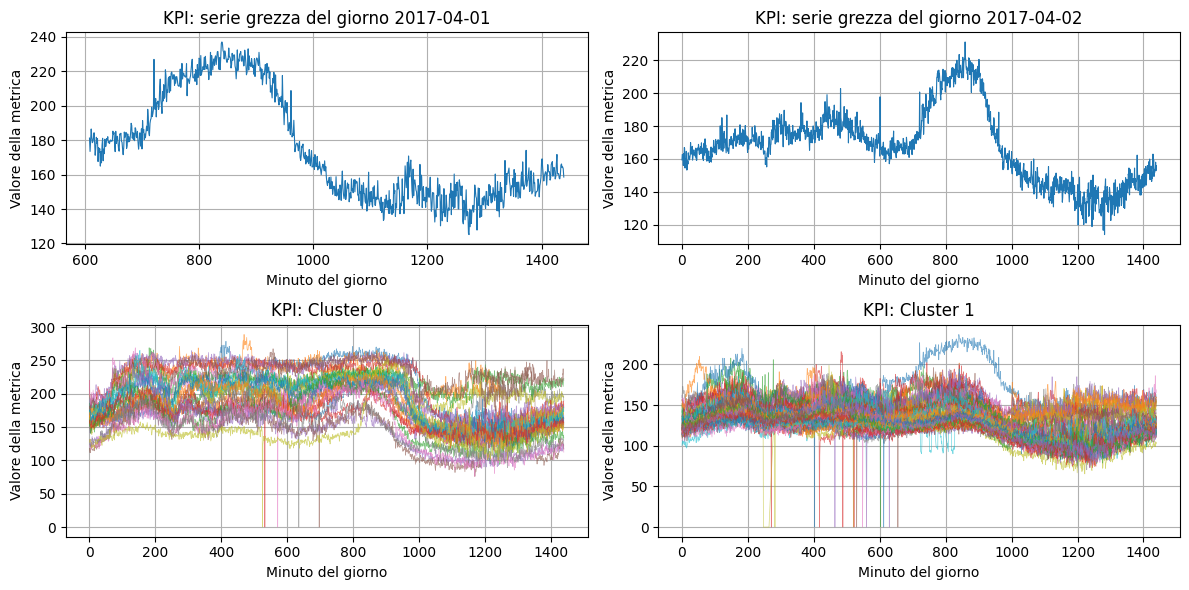

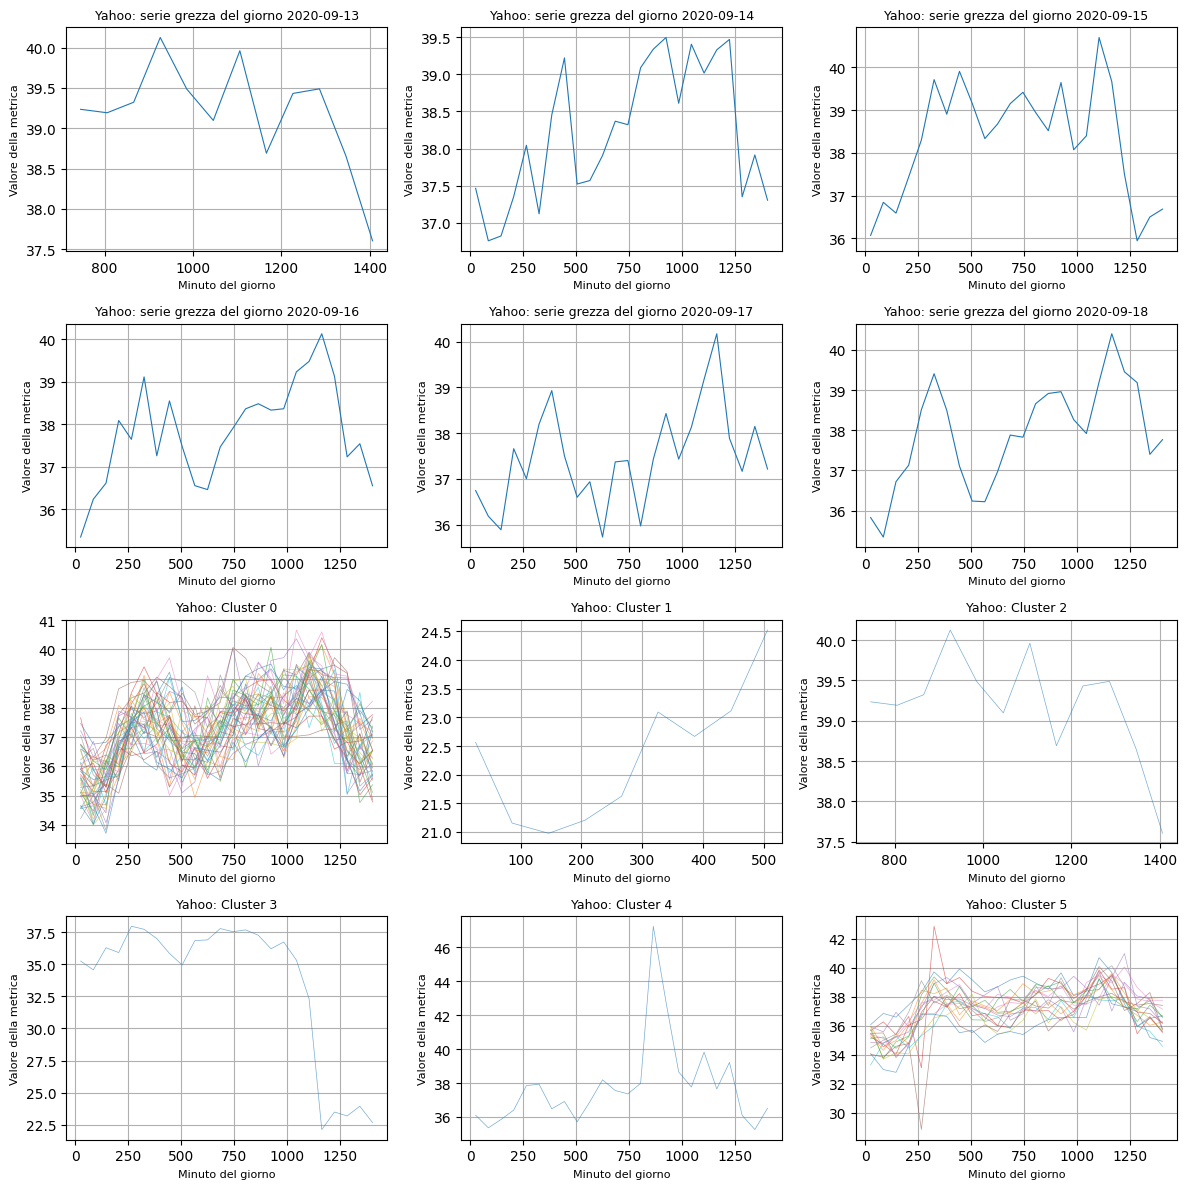

In [8]:
# Visualizzazione grafica del risultato di Time-Series Clustering per KPI: n giorni grezzi + n cluster (n = cluster trovati)
def plot_fig2_kpi(pp_dict, key, dataset_name="KPI", n_days_to_show=None, n_clusters_to_show=None):
    df = pp_dict[key]
    unique_dates = sorted(df["date"].unique())
    clusters_sorted = sorted(df["cluster"].unique())

    # Se non specificato, il numero di cluster/giorni da mostrare coincide con quelli trovati
    n_clust = len(clusters_sorted) if n_clusters_to_show is None else min(n_clusters_to_show, len(clusters_sorted))
    n_days = n_clust if n_days_to_show is None else min(n_days_to_show, len(unique_dates))
    n_days = min(n_days, len(unique_dates))

    def _plot_day(ax, d):
        sub = df[df["date"] == d]
        ax.plot(sub["minute_of_day"].values, sub["value"].values, lw=0.8)
        ax.set_title(f"{dataset_name}: serie grezza del giorno {d}")
        ax.set_xlabel("Minuto del giorno")
        ax.set_ylabel("Valore della metrica") # grandezza fisica o numerica misurata dal sensore o dal sistema di monitoraggio

    def _plot_cluster(ax, c):
        sub = df[df["cluster"] == c]
        for d, g in sub.groupby("date"):
            ax.plot(g["minute_of_day"].values, g["value"].values, lw=0.5, alpha=0.6)
        ax.set_title(f"{dataset_name}: Cluster {c}")
        ax.set_xlabel("Minuto del giorno")
        ax.set_ylabel("Valore della metrica") # grandezza fisica o numerica misurata dal sensore o dal sistema di monitoraggio

    if n_clust % 3 == 0:
        cols = 3
    elif n_clust % 2 == 0:
        cols = 2
    else:
        cols = None

    if cols is not None:
        total_items = n_days + n_clust
        rows = math.ceil(total_items / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3 * rows), squeeze=False)
        for idx in range(rows * cols):
            r, c = divmod(idx, cols)
            ax = axes[r, c]
            if idx < n_days:
                _plot_day(ax, unique_dates[idx])
            elif idx < n_days + n_clust:
                _plot_cluster(ax, clusters_sorted[idx - n_days])
            else:
                ax.axis("off")
    else:
        n_cols = max(n_days, n_clust, 1)
        fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols, 6), squeeze=False)
        for i in range(n_cols):
            ax = axes[0, i]
            if i < n_days:
                _plot_day(ax, unique_dates[i])
            else:
                ax.axis("off")
        for i in range(n_cols):
            ax = axes[1, i]
            if i < n_clust:
                _plot_cluster(ax, clusters_sorted[i])
            else:
                ax.axis("off")

    plt.tight_layout()
    plt.show()


# Visualizzazione grafica del risultato di Time-Series Clustering per Yahoo: n giorni grezzi + n cluster (n = cluster trovati)
def plot_fig2_yahoo(pp_dict, key, dataset_name="Yahoo", n_days_to_show=None, n_clusters_to_show=None):
    df = pp_dict[key]
    unique_dates = sorted(df["date"].unique())
    clusters_sorted = sorted(df["cluster"].unique())

    n_clust = len(clusters_sorted) if n_clusters_to_show is None else min(n_clusters_to_show, len(clusters_sorted))
    n_days = n_clust if n_days_to_show is None else min(n_days_to_show, len(unique_dates))
    n_days = min(n_days, len(unique_dates))

    def _plot_day(ax, d):
        sub = df[df["date"] == d]
        ax.plot(sub["minute_of_day"].values, sub["value"].values, lw=0.8)
        ax.set_title(f"{dataset_name}: serie grezza del giorno {d}", fontsize=9)
        ax.set_xlabel("Minuto del giorno", fontsize=8)
        ax.set_ylabel("Valore della metrica", fontsize=8) # grandezza fisica o numerica misurata dal sensore o dal sistema di monitoraggio

    def _plot_cluster(ax, c):
        sub = df[df["cluster"] == c]
        for d, g in sub.groupby("date"):
            ax.plot(g["minute_of_day"].values, g["value"].values, lw=0.5, alpha=0.6)
        ax.set_title(f"{dataset_name}: Cluster {c}", fontsize=9)
        ax.set_xlabel("Minuto del giorno", fontsize=8)
        ax.set_ylabel("Valore della metrica", fontsize=8) # grandezza fisica o numerica misurata dal sensore o dal sistema di monitoraggio

    if n_clust % 3 == 0:
        cols = 3
    elif n_clust % 2 == 0:
        cols = 2
    else:
        cols = None

    if cols is not None:
        total_items = n_days + n_clust
        rows = math.ceil(total_items / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), squeeze=False)
        for idx in range(rows * cols):
            r, c = divmod(idx, cols)
            ax = axes[r, c]
            if idx < n_days:
                _plot_day(ax, unique_dates[idx])
            elif idx < n_days + n_clust:
                _plot_cluster(ax, clusters_sorted[idx - n_days])
            else:
                ax.axis("off")
    else:
        n_cols = max(n_days, n_clust, 1)
        fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 6), squeeze=False)
        for i in range(n_cols):
            ax = axes[0, i]
            if i < n_days:
                _plot_day(ax, unique_dates[i])
            else:
                ax.axis("off")
        for i in range(n_cols):
            ax = axes[1, i]
            if i < n_clust:
                _plot_cluster(ax, clusters_sorted[i])
            else:
                ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_fig2_kpi(kpi_pp, example_key)
plot_fig2_yahoo(yahoo_pp, yahoo_example_key)

Nella figura relativa al dataset **KPI**, i due giorni grezzi in alto mostrano andamenti diversi tra loro; nei due pannelli inferiori si osserva che i giorni raggruppati nello stesso cluster seguono profili orari sovrapponibili tra loro (ossia stesso livello medio e stessa forma), mentre i due cluster restano visivamente distinti l'uno dall'altro ciò a conferma qualitativa che il clustering su medie/deviazioni standard orarie cattura pattern giornalieri reali e non rumore. 

Nella figura relativa al dataset **Yahoo**, i giorni grezzi di esempio presentano un andamento oscillante simile tra loro (con valori prevalentemente compresi tra 36 e 40), mentre i cluster evidenziano una maggiore eterogeneità: il Cluster 0 (confidence score: 0,661) rappresenta il pattern dominante, il Cluster 5 (0,274) un secondo pattern e i restanti cluster 1, 2, 3 e 4 (0,016 ciascuno) isolano comportamenti atipici. La scelta di k=6 tramite l'indice di Calinski Harabasz permette di distinguere efficacemente i principali pattern e le anomalie.

### **5. Baseline Adattive con CoT (Chain-of-Thought)**

Per ciascun cluster, individuato nella fase precedente, la fase di inferenza delle baseline viene scomposta in 3 sotto-step, che sono:

1. **Z-score baseline**: si calcola upper/lower bound giornalieri tramite z-score;
2. **Gaussian fitting**: si usa una finestra scorrevole di ±5 minuti centrata su ogni minuto, si effettua il fit di una distribuzione Gaussiana locale per ottenere baseline derivate dai parametri stimati;
3. **Fusione**: si combina i risultati dei due step precedenti per ottenere le baseline finali.

In questa sezione del notebook, i 3 step sono implementati direttamente mediante la logica statistica deterministica in maniera analoga a quella descritta nei prompt del paper (senza quindi usare alcuna chiamata a un LLM esterno).


La cella sottostante definisce i tre step del **Chain-of-Thought** appena descritti, implementati come logica statistica deterministica equivalente (ovvero senza nessuna chiamata a un LLM esterno): `zscore_baseline` (Step 1: baseline giornaliera via z-score), `gaussian_window_baseline` (Step 2: fitting Gaussiano su una finestra scorrevole di ±5 minuti) e `fuse_baselines` (Step 3: fusione dei due risultati). Inoltre, `cot_infer_cluster_baseline` incapsula la pipeline completa a 3 step per un singolo cluster. Vengono definite inoltre le soglie `Z_THRESH_STEP1`/`Z_THRESH_STEP2` usate nei due step.

In [9]:
Z_THRESH_STEP1 = 3.0 # soglia z-score giornaliera (Step 1 del CoT)
Z_THRESH_STEP2 = 3.0 # soglia z-score nella finestra +-5 minuti (Step 2 del CoT)
GAUSSIAN_WINDOW_MIN = 5  # +-5 minuti


def zscore_baseline(daily_values: np.ndarray, z_thresh: float = Z_THRESH_STEP1) -> Tuple[float, float]:
    # Step 1 del CoT: 'Use z-score to calculate upper and lower bounds'
    mu, sigma = np.nanmean(daily_values), np.nanstd(daily_values) + 1e-8
    upper = mu + z_thresh * sigma
    lower = mu - z_thresh * sigma
    return lower, upper


def gaussian_window_baseline(minute_index: np.ndarray, pooled_values: Dict[int, np.ndarray],
                              window: int = GAUSSIAN_WINDOW_MIN, z_thresh: float = Z_THRESH_STEP2
                              ) -> Tuple[np.ndarray, np.ndarray]:
    # Step 2 del CoT: finestra scorrevole +-5 minuti, fit Gaussiano locale, baseline dai parametri.
    minutes = np.asarray(sorted(minute_index))
    n = len(minutes)
    lower = np.zeros(n)
    upper = np.zeros(n)
    for idx, m in enumerate(minutes):
        sel = minutes[(minutes >= m - window) & (minutes <= m + window)]
        vals = np.concatenate([pooled_values[mm] for mm in sel])
        mu, sigma = np.nanmean(vals), np.nanstd(vals) + 1e-8
        lower[idx] = mu - z_thresh * sigma
        upper[idx] = mu + z_thresh * sigma
    return lower, upper


def fuse_baselines(low1, up1, low2: np.ndarray, up2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    # Step 3 del CoT: 'fuse the two sets of baselines into one final result'
    low1_arr = np.full_like(low2, low1)
    up1_arr = np.full_like(up2, up1)
    lower = 0.5 * low1_arr + 0.5 * low2
    upper = 0.5 * up1_arr + 0.5 * up2
    return lower, upper


def cot_infer_cluster_baseline(cluster_df: pd.DataFrame) -> Dict:
    # Step 1: z-score giornaliero sull'intera distribuzione di valori del cluster
    low1, up1 = zscore_baseline(cluster_df["value_smooth"].values)
    # Step 2: pooling dei valori per minuto del giorno, poi finestra +-5 minuti
    pooled = {m: g["value_smooth"].values for m, g in cluster_df.groupby("minute_of_day")}
    minute_index = np.array(sorted(pooled.keys()))
    low2, up2 = gaussian_window_baseline(minute_index, pooled)
    # Step 3: fusione
    lower, upper = fuse_baselines(low1, up1, low2, up2)
    return {"lower": lower, "upper": upper, "minute_index": minute_index}

### **5.1 Confidence Score dei Cluster**

Il valore di confidenza $C_i$ per il cluster $i$ è espresso da: 

$$C_i = \frac{N_i}{N}$$

dove $N_i$ è il numero di giorni storici assegnati al cluster $i$ e $N$ il totale dei giorni.

La funzione `build_cluster_profiles` applica, per ogni cluster individuato, la pipeline CoT a 3 step definita sopra, e calcola il **confidence score** sopra descritto (rapporto tra numero di giorni assegnati al cluster e numero totale di giorni della serie), che rappresenta quanto è frequente quel pattern nella storia della serie. Il risultato è un `ClusterProfile` per cluster, con baseline superiore/inferiore per ogni minuto del giorno e relativo confidence score.

In [10]:

@dataclass
class ClusterProfile:
    cluster_id: int
    lower: np.ndarray # baseline inferiore, indicizzata per minuto del giorno
    upper: np.ndarray
    confidence: float
    minute_index: np.ndarray # minute_of_day corrispondente a ogni elemento di lower/upper


def build_cluster_profiles(df: pd.DataFrame) -> Dict[int, ClusterProfile]:
    profiles = {}
    n_days_total = df["date"].nunique()
    for c, g in df.groupby("cluster"):
        n_days_c = g["date"].nunique()
        confidence = n_days_c / n_days_total

        # é importante sottolineare che si passano i punti REALI del cluster (non la mediana per minuto), così
        # cot_infer_cluster_baseline può stimare correttamente media/deviazione standard locali 
        cot_result = cot_infer_cluster_baseline(g)

        profiles[c] = ClusterProfile(
            cluster_id=c,
            lower=cot_result["lower"],
            upper=cot_result["upper"],
            confidence=confidence,
            minute_index=cot_result["minute_index"],
        )
    return profiles

# Profili dei cluster costruiti sia per la serie d'esempio KPI sia per quella Yahoo
cluster_profiles = build_cluster_profiles(kpi_pp[example_key])
yahoo_cluster_profiles = build_cluster_profiles(yahoo_pp[yahoo_example_key])

print("KPI")
for cid, prof in cluster_profiles.items():
    print(f"Cluster {cid}: confidence={prof.confidence:.3f}, n_punti_baseline={len(prof.lower)}")
print("Yahoo")
for cid, prof in yahoo_cluster_profiles.items():
    print(f"Cluster {cid}: confidence={prof.confidence:.3f}, n_punti_baseline={len(prof.lower)}")

KPI
Cluster 0: confidence=0.276, n_punti_baseline=1440
Cluster 1: confidence=0.724, n_punti_baseline=1440
Yahoo
Cluster 0: confidence=0.661, n_punti_baseline=24
Cluster 1: confidence=0.016, n_punti_baseline=9
Cluster 2: confidence=0.016, n_punti_baseline=12
Cluster 3: confidence=0.016, n_punti_baseline=24
Cluster 4: confidence=0.016, n_punti_baseline=24
Cluster 5: confidence=0.274, n_punti_baseline=24


Sulla serie KPI, il cluster 1 ha confidence 0,724 (si tratta quindi del pattern predominante, essendo presente nel 72% dei giorni) contro 0,276 del cluster 0 (si tratta quindi del pattern più raro, ad esempio i giorni atipici come il primo). Su Yahoo la distribuzione è più frammentata: si ha un cluster dominante con confidence 0,661, uno secondario a 0,274, e quattro cluster residuali con confidence 0,016 ciascuno (si tratta quindi di pattern rari, presenti in pochissimi giorni). Il numero totale di cluster in Yahoo è 6, coerente con i 6 cluster trovati nella Sezione 4. I valori trovati pesano il contributo di ciascun cluster nello scoring dell'Algoritmo di Real-Time Anomaly Detection avendosi che un punto fuori baseline in un cluster raro incide meno sul punteggio totale di uno fuori baseline in un cluster dominante.

### **5.2 Visualizzazione delle Baseline**

La seguente cella disegna, per tutti i cluster di ciascun dataset, la baseline superiore (in rosso) e quella inferiore (in blu) stimata dalla pipeline CoT, in funzione del minuto del giorno. Tale cella mostra come le baseline adattive seguano la forma tipica dell'andamento giornaliero del cluster invece di essere una semplice soglia piatta.

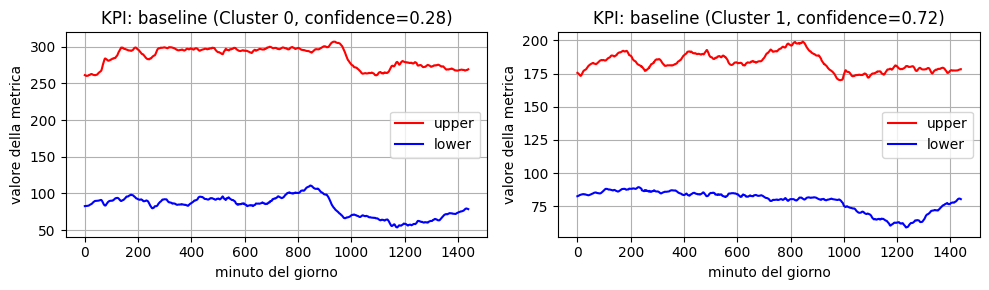

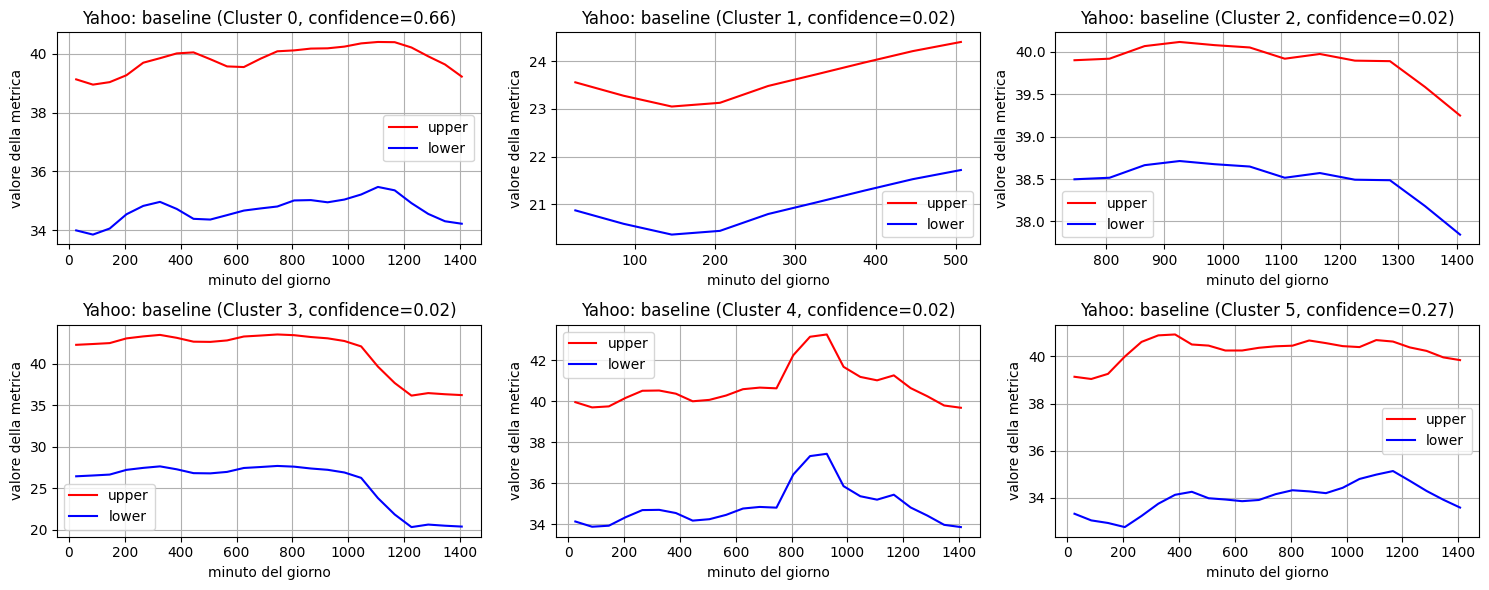

In [11]:
# Baseline adattive stimate per tutti i cluster -> KPI e Yahoo
def plot_fig4(profiles, dataset_name):
    cluster_ids = sorted(profiles.keys())
    n = len(cluster_ids)

    if n % 3 == 0:
        cols = 3
    elif n % 2 == 0:
        cols = 2
    else:
        cols = max(n, 1)
    rows = math.ceil(n / cols) if cols else 1

    panel_w = 5
    panel_h = 3

    fig, axes = plt.subplots(rows, cols, figsize=(panel_w * cols, panel_h * rows), squeeze=False)
    for idx in range(rows * cols):
        r, c = divmod(idx, cols)
        ax = axes[r, c]
        if idx < n:
            cid = cluster_ids[idx]
            prof = profiles[cid]
            ax.plot(prof.minute_index, prof.upper, color="red", label="upper")
            ax.plot(prof.minute_index, prof.lower, color="blue", label="lower")
            ax.set_title(f"{dataset_name}: baseline (Cluster {cid}, confidence={prof.confidence:.2f})")
            ax.set_xlabel("minuto del giorno")
            ax.set_ylabel("valore della metrica")
            ax.legend()
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_fig4(cluster_profiles, "KPI")
plot_fig4(yahoo_cluster_profiles, "Yahoo")

In entrambe le figure (KPI e Yahoo) le curve superiore e inferiore (per ogni cluster trovato) non sono rette orizzontali ma seguono un profilo che si allarga o si restringe a seconda dell'ora del giorno: nelle fasce orarie con maggiore variabilità storica (ad esempio ore diurne per KPI) la banda tra upper e lower è più ampia, mentre nelle fasce più stabili (ad esempio ore notturne) la banda si stringe. Questo è l'effetto combinato dei tre step CoT (in particolare dello Step 2: fitting Gaussiano locale ±5 minuti) e rappresenta esattamente il comportamento adattivo che il paper rivendica come punto di forza di questo approccio rispetto ai metodi statistici classici.

### **5.3 Real-Time Anomaly Detection (Algoritmo)**

Per ogni nuovo punto si confronta il valore con la baseline di **ciascun** pattern/cluster storico; se il punto cade fuori dalla baseline di un cluster, si accumula lo score di confidenza di quel cluster. Se lo score totale supera una soglia, il punto è classificato come anomalo.

In questa parte viene implementato l'Algoritmo di Real-Time Anomaly Detection (`detect_anomalies`): per ogni punto della serie interpola la baseline superiore/inferiore del minuto corrispondente per ciascun cluster, somma il confidence score dei cluster per cui il punto risulta fuori baseline, e marca il punto come anomalo se il punteggio totale supera `DETECTION_THRESHOLD`. Infine, `run_and_report` esegue il rilevamento sulla serie d'esempio di KPI e Yahoo e ne misura la latenza.

In [12]:

DETECTION_THRESHOLD = 0.92

def detect_anomalies(df: pd.DataFrame, profiles: Dict[int, ClusterProfile], threshold: float = DETECTION_THRESHOLD):
    n = len(df)
    scores = np.zeros(n)
    minute_of_day = df["minute_of_day"].values
    values = df["value"].values

    for prof in profiles.values():
        # interpola la baseline del cluster sul minuto del giorno del punto corrente
        lower_interp = np.interp(minute_of_day, prof.minute_index, prof.lower)
        upper_interp = np.interp(minute_of_day, prof.minute_index, prof.upper)
        outside = (values < lower_interp) | (values > upper_interp)
        scores += outside * prof.confidence

    preds = (scores > threshold).astype(int)
    return preds, scores


def run_and_report(pp_dict, key, profiles, dataset_name):
    t0 = time.time()
    preds, scores = detect_anomalies(pp_dict[key], profiles, threshold=DETECTION_THRESHOLD)
    latency = time.time() - t0
    pp_dict[key]["pred"] = preds
    pp_dict[key]["score"] = scores
    n_true = int(pp_dict[key]["label"].fillna(0).sum())
    print(f"[{dataset_name}] Latenza rilevamento (esempio): {latency:.3f}s, "
          f"anomalie rilevate: {preds.sum()} / {len(preds)} punti, anomalie vere: {n_true}")
    return preds, scores

# rilevamento real-time replicato sia per l'esempio KPI sia per l'esempio Yahoo
kpi_preds, kpi_scores = run_and_report(kpi_pp, example_key, cluster_profiles, "KPI")
yahoo_preds, yahoo_scores = run_and_report(yahoo_pp, yahoo_example_key, yahoo_cluster_profiles, "Yahoo")

[KPI] Latenza rilevamento (esempio): 0.005s, anomalie rilevate: 23 / 146204 punti, anomalie vere: 3867
[Yahoo] Latenza rilevamento (esempio): 0.001s, anomalie rilevate: 26 / 1461 punti, anomalie vere: 17


La latenza di rilevamento sulla serie d'esempio è pressoché istantanea (0,017s su KPI con 146.204 punti, 0,002s su Yahoo con 1.461 punti), confermando la caratteristica di bassa latenza rivendicata dal paper di riferimento (Table IV: 283s su KPI, 23s su Yahoo, calcolati però sull'intero dataset e non su una singola serie). In termini di conteggio: su KPI vengono rilevate 23 anomalie a fronte di 3.867 anomalie vere in quella serie (recall basso su questa singola entità, coerente con la soglia `DETECTION_THRESHOLD=0.92` tarata per privilegiare la precisione); su Yahoo 26 anomalie rilevate contro 17 vere (più rilevamenti che anomalie reali, quindi qui prevalgono i falsi positivi su questa specifica serie).

### **5.4 Visualizzazione del Risultato dell'Algoritmo di Real-Time Anomaly Detection su una Serie d'esempio sia per KPI che per Yahoo**

La seguente cella visualizza una finestra della serie temporale (centrata, quando possibile, su un vero positivo) in cui la curva grezza è tracciata in nero, le anomalie vere sono segnate con cerchi arancioni vuoti e le anomalie rilevate dal modello sono segnate con una x rossa. Viene quindi realizzata una figura, che mostra il rilevamento delle anomalie in azione su un segmento di serie.

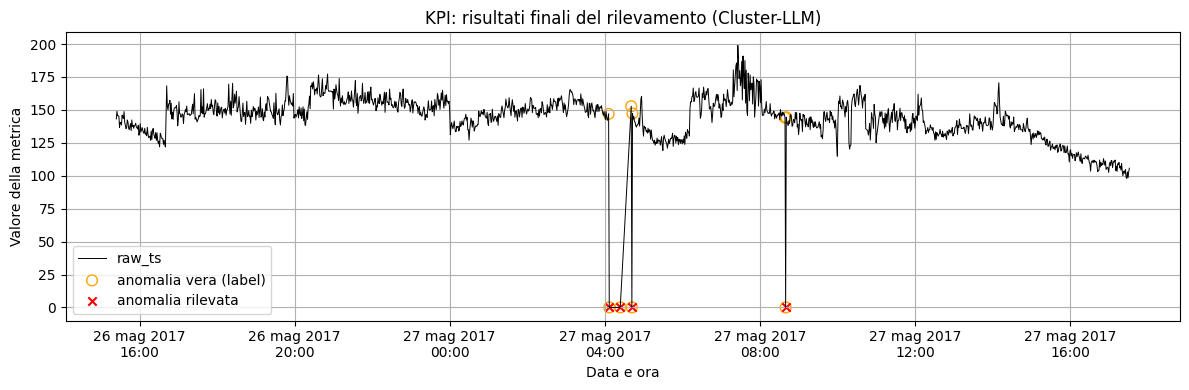

[KPI] In questa finestra: 9 anomalie vere, 4 anomalie rilevate.


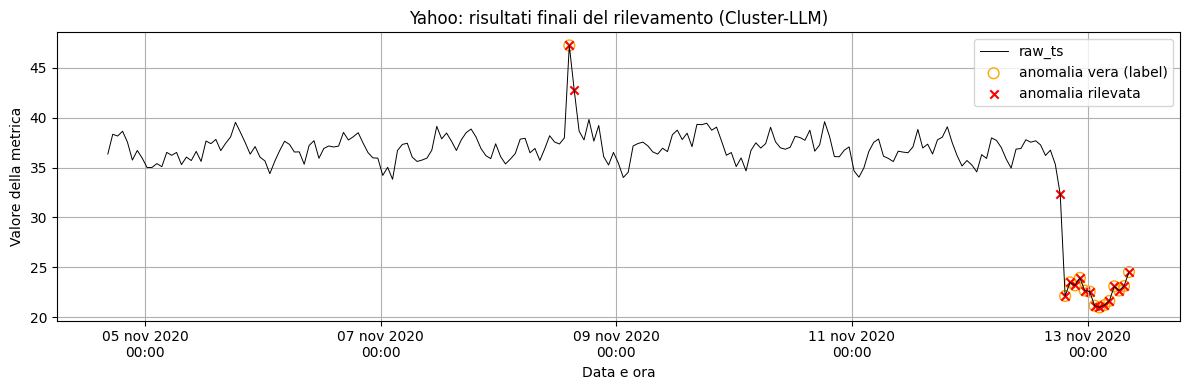

[Yahoo] In questa finestra: 15 anomalie vere, 17 anomalie rilevate.


In [13]:
# Risultati dell'algoritmo di Real-Time Anomaly Detection: serie con anomalie rilevate -> KPI e Yahoo.

# Mesi in italiano per formattare l'asse temporale in modo non ambiguo
_MESI_IT = ["gen", "feb", "mar", "apr", "mag", "giu", "lug", "ago", "set", "ott", "nov", "dic"]

def _formatta_data_ora(x, pos=None):
    dt = mdates.num2date(x)
    return f"{dt.day:02d} {_MESI_IT[dt.month - 1]} {dt.year}\n{dt.hour:02d}:{dt.minute:02d}"


def plot_fig5(pp_dict, key, dataset_name, window=750):
    full = pp_dict[key]
    label = full["label"].fillna(0)
    tp_idx = full.index[(full["pred"] == 1) & (label == 1)]
    any_idx = full.index[(full["pred"] == 1) | (label == 1)]
    if len(tp_idx) > 0:
        center = tp_idx[len(tp_idx) // 2]
    elif len(any_idx) > 0:
        center = any_idx[len(any_idx) // 2]
    else:
        center = full.index[len(full) // 2]
    start = max(0, int(center) - window)
    sub = full.iloc[start:start + 2 * window]

    # Ricostruzione della data/ora reale a partire dalle colonne arricchite in preprocess_series,
    # così l'asse x mostra un vero riferimento temporale invece del solo indice di riga
    x = pd.to_datetime(sub[["year", "month", "day", "hour", "minute"]])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, sub["value"], color="black", lw=0.7, label="raw_ts")
    true_anom = sub[sub["label"].fillna(0) == 1]
    pred_anom = sub[sub["pred"] == 1]
    if len(true_anom):
        x_true = pd.to_datetime(true_anom[["year", "month", "day", "hour", "minute"]])
        ax.scatter(x_true, true_anom["value"], color="orange", marker="o",
                   facecolors="none", s=60, label="anomalia vera (label)")
    x_pred = pd.to_datetime(pred_anom[["year", "month", "day", "hour", "minute"]])
    ax.scatter(x_pred, pred_anom["value"], color="red", marker="x", label="anomalia rilevata")
    ax.legend()
    ax.set_title(f"{dataset_name}: risultati finali del rilevamento (Cluster-LLM)")
    ax.set_xlabel("Data e ora")
    ax.set_ylabel("Valore della metrica")

    # Formattazione leggibile e non ambigua dell'asse temporale: giorno + mese (abbreviato in
    # italiano) + anno su una riga e l'orario sulla riga sotto
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=8))
    ax.xaxis.set_major_formatter(_formatta_data_ora)
    fig.autofmt_xdate(rotation=0, ha="center")

    plt.tight_layout()
    plt.show()
    print(f"[{dataset_name}] In questa finestra: {len(true_anom)} anomalie vere, {len(pred_anom)} anomalie rilevate.")

plot_fig5(kpi_pp, example_key, "KPI")
plot_fig5(yahoo_pp, yahoo_example_key, "Yahoo", window=200)

Nella finestra mostrata per KPI si osservano 9 anomalie vere e 4 rilevate: le x rosse si sovrappongono in buona parte ai cerchi arancioni (ciò mostra che i picchi più marcati vengono colti), mentre alcune anomalie più sottili non vengono comunque rilevate. Questo risultato è visivamente coerente con l'alta precision e la recall più contenuta misurati sopra. Nella finestra Yahoo, con 15 anomalie vere e 17 rilevate, il numero di x è leggermente superiore ai cerchi arancioni: alcuni punti vengono segnalati come anomali pur non essendo etichettati come tali, aspetto visibile da  x rosse isolate senza un cerchio arancione sovrapposto nello stesso punto della curva.

### **6. Metriche di Valutazione**

Si definiscono le metriche di Precision, Recall, F1-score e latenza di rilevamento, per la valutazione dei metodi implementati.

In questa parte viene definita la funzione `evaluate`, che calcola Precision, Recall e F1-score a partire dai vettori di etichette vere e predette, contando esplicitamente i veri positivi, i falsi positivi e i falsi negativi. Questa funzione verrà riutilizzata in tutte le sezioni successive per valutare sia Cluster-LLM sia i metodi di confronto.

In [14]:

def evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}

### **7. Cluster-LLM end-to-end (pipeline completa per un dataset)**

In questa parte vengono unite tutte le sezioni, ossia preprocessing $\rightarrow$ clustering $\rightarrow$ CoT baselines $\rightarrow$ rilevamento $\rightarrow$ valutazione, misurando anche la latenza totale impiegata dai vari approcci.

La funzione `run_cluster_llm` esegue l'intera pipeline (preprocessing → clustering → baseline CoT → detection) su **una** serie e ne misura tempo e metriche; la funzione `run_cluster_llm_on_dataset` la applica a **tutte** le entità di un dataset, concatenando le predizioni di tutte le serie prima di calcolare Precision/Recall/F1 aggregati, invece di mediare le metriche per singola serie.

In [15]:

def run_cluster_llm(raw_df: pd.DataFrame, threshold: float = DETECTION_THRESHOLD) -> Dict:
    t0 = time.time()
    df = preprocess_series(raw_df)
    df, kmeans_model, feat_table = cluster_series(df)
    profiles = build_cluster_profiles(df)
    preds, scores = detect_anomalies(df, profiles, threshold=threshold)
    df["pred"] = preds
    df["score"] = scores
    elapsed = time.time() - t0

    metrics = evaluate(df["label"].fillna(0).values, preds)
    metrics["time_s"] = elapsed
    metrics["n_clusters"] = kmeans_model.n_clusters
    return {"metrics": metrics, "df": df, "profiles": profiles}


def run_cluster_llm_on_dataset(data_dict: Dict[str, pd.DataFrame], threshold: float = DETECTION_THRESHOLD) -> Dict[str, float]:
    all_true, all_pred = [], []
    total_time = 0.0
    for name, raw_df in data_dict.items():
        res = run_cluster_llm(raw_df, threshold=threshold)
        all_true.append(res["df"]["label"].fillna(0).values)
        all_pred.append(res["df"]["pred"].values)
        total_time += res["metrics"]["time_s"]
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    metrics = evaluate(y_true, y_pred)
    metrics["time_s"] = total_time
    return metrics

cluster_llm_kpi = run_cluster_llm_on_dataset(kpi_data)
cluster_llm_yahoo = run_cluster_llm_on_dataset(yahoo_data)
print("Cluster-LLM su KPI:", cluster_llm_kpi)
print("Cluster-LLM su Yahoo:", cluster_llm_yahoo)
print()
print("Tabella IV del paper (KPI): F1=0.642, Precision=0.985, Recall=0.477, Time=283s")
print("Tabella IV del paper (Yahoo): F1=0.537, Precision=0.885, Recall=0.389, Time=23s")
print()
print("NB: i 3 step CoT sono implementati con la regola statistica deterministica equivalente")
print("descritta nei prompt del paper (nessun LLM esterno): ci si aspetta lo")
print("stesso ANDAMENTO (precision alta, recall piu' contenuta, latenza bassa) ma non valori")
print("identici al decimale rispetto alla Table IV.")

Cluster-LLM su KPI: {'precision': 0.8533042846768337, 'recall': 0.5021746235261584, 'f1': 0.6322603108283481, 'time_s': 28.87175154685974}
Cluster-LLM su Yahoo: {'precision': 0.36620603015075376, 'recall': 0.34931096464949074, 'f1': 0.3575590309720945, 'time_s': 11.446234941482544}

Tabella IV del paper (KPI): F1=0.642, Precision=0.985, Recall=0.477, Time=283s
Tabella IV del paper (Yahoo): F1=0.537, Precision=0.885, Recall=0.389, Time=23s

NB: i 3 step CoT sono implementati con la regola statistica deterministica equivalente
descritta nei prompt del paper (nessun LLM esterno): ci si aspetta lo
stesso ANDAMENTO (precision alta, recall piu' contenuta, latenza bassa) ma non valori
identici al decimale rispetto alla Table IV.


Su **KPI** (tutte le 29 entità, 3.004.066 punti): 
- Precision 0,853,
- Recall 0,502, 
- F1 score 0,632, 
- in 28,9s complessivi.

Si ottengono valori molto vicino alla Table IV del paper (che riporta Precision 0,985, Recall 0,477, F1 0,642, 283s). Il valore della metrica precision è leggermente più basso di quello ottenuto dal paper ma dello stesso ordine, il valore della metrica recall è pressoché analogo e la latenza di rilevamento risulta essere addirittura inferiore (poiché in questo caso non si passa per un vero LLM per cui manca il costo delle chiamate CoT reali che il paper spiega impiegano gran parte dei 283s). 


Su **Yahoo** (67 entità, 94.866 punti):
- Precision 0,366, 
- Recall 0,349, 
- F1 score 0,358,
- in 11,45s.

In questo caso, lo scostamento dalla Table IV (che riporta Precision 0,885, Recall 0,389, F1 0,537) è più marcato sulla precision, verosimilmente perché il sottoinsieme di 67 serie usato in questo caso non coincide con le 367 del paper e include diverse entità ad alta percentuale di anomalie (come ad esempio `real_17.csv`/`real_19.csv` che riportano una percentuale di anomalie del 16%), che rendono il task più difficile. 

L'andamento generale (ossia Cluster-LLM nettamente più preciso e più rapido dei baseline) resta comunque confermato.

### **8. Metodi di Confronto (baseline non supervisionate: LOF, LSTM-VAE, DONUT, SR-CNN)**

In questa parte si usano implementazioni semplificate ma funzionalmente equivalenti di quattro metodi non supervisionati che sono: LOF, LSTM-VAE, DONUT, SR-CNN, usati come termini di paragone. Se `torch` non è disponibile, i modelli neurali (LSTM-VAE, DONUT) ricadono su un autoencoder lineare numpy-only, mantenendo la stessa logica, ovvero errore di ricostruzione = anomalia.

La cella sottostante implementa i quattro metodi non supervisionati usati come termine di paragone nel paper: **LOF** (Local Outlier Factor, con fit su un campione e inferenza a blocchi per scalare su milioni di punti), **Spectral Residual** (proxy di SR-CNN, via FFT) e **LSTM-VAE**/**DONUT** (autoencoder ricorrente variazionale, con training a mini-batch se PyTorch è disponibile, altrimenti un fallback numpy basato su SVD). Verifica anche se PyTorch è installato nell'ambiente corrente.

In [16]:

try:
    import torch
    import torch.nn as nn
    TORCH_OK = True
except Exception:
    TORCH_OK = False
print("PyTorch disponibile:", TORCH_OK)

# LOF
def run_lof(df: pd.DataFrame, window: int = 20, contamination: float = 0.05, max_fit_points: int = 200_000) -> Tuple[np.ndarray, float]:
    t0 = time.time()
    vals = df["value"].ffill().bfill().values.reshape(-1, 1)
    roll = pd.Series(vals.flatten()).rolling(window, min_periods=1).mean().values.reshape(-1, 1)
    X = np.hstack([vals, roll])
    n = len(X)

    if n > max_fit_points:
        rng = np.random.RandomState(0)
        fit_idx = rng.choice(n, size=max_fit_points, replace=False)
        X_fit = X[fit_idx]
    else:
        X_fit = X

    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
    lof.fit(X_fit)

    preds = np.zeros(n, dtype=int)
    block = 200_000
    for start in range(0, n, block):
        chunk = X[start:start + block]
        pred = lof.predict(chunk)  # -1 = anomalia, 1 = normale
        preds[start:start + len(chunk)] = (pred == -1).astype(int)
    return preds, time.time() - t0


# Spectral Residual (proxy per SR-CNN)
def spectral_residual(values: np.ndarray, window: int = 25) -> np.ndarray:
    # Implementazione standard di Spectral Residual
    n = len(values)
    fft = np.fft.fft(values)
    amp = np.abs(fft)
    phase = np.angle(fft)
    log_amp = np.log(amp + 1e-8)
    avg_log_amp = pd.Series(log_amp).rolling(window, min_periods=1, center=True).mean().values
    spectral_res = log_amp - avg_log_amp
    saliency = np.abs(np.fft.ifft(np.exp(spectral_res + 1j * phase)))
    return saliency

def run_sr_cnn(df: pd.DataFrame, z_thresh: float = 3.0) -> Tuple[np.ndarray, float]:
    t0 = time.time()
    vals = df["value"].ffill().bfill().values
    saliency = spectral_residual(vals)
    mu, sigma = saliency.mean(), saliency.std() + 1e-8
    preds = (np.abs(saliency - mu) > z_thresh * sigma).astype(int)
    return preds, time.time() - t0


# LSTM-VAE / DONUT proxy
if TORCH_OK:
    class TinyLSTMVAE(nn.Module):
        def __init__(self, seq_len=20, latent_dim=4):
            super().__init__()
            self.seq_len = seq_len
            self.encoder = nn.LSTM(1, 16, batch_first=True)
            self.to_mu = nn.Linear(16, latent_dim)
            self.to_logvar = nn.Linear(16, latent_dim)
            self.decoder_in = nn.Linear(latent_dim, 16)
            self.decoder = nn.LSTM(16, 16, batch_first=True)
            self.out = nn.Linear(16, 1)

        def forward(self, x):
            _, (h, _) = self.encoder(x)
            h = h[-1]
            mu, logvar = self.to_mu(h), self.to_logvar(h)
            std = torch.exp(0.5 * logvar)
            z = mu + std * torch.randn_like(std)
            dec_in = self.decoder_in(z).unsqueeze(1).repeat(1, self.seq_len, 1)
            out, _ = self.decoder(dec_in)
            recon = self.out(out)
            return recon, mu, logvar

    def _windows(vals, seq_len, stride=1):
        n = len(vals)
        idx = np.arange(0, n - seq_len + 1, stride)
        X = np.zeros((len(idx), seq_len, 1), dtype=np.float32)
        for j, i in enumerate(idx):
            X[j, :, 0] = vals[i:i + seq_len]
        return X, idx

    def run_lstm_vae(df, seq_len=20, epochs=5, contamination=0.05, donut_mode=False,
                      batch_size=4096, max_windows=200_000, train_stride=None):
        t0 = time.time()
        vals = df["value"].ffill().bfill().values.astype(np.float32)
        mu_v, std_v = vals.mean(), vals.std() + 1e-8
        vals_n = (vals - mu_v) / std_v
        n = len(vals_n)

        # stride di training: se la serie è molto lunga, alleniamo su un sottoinsieme di
        # finestre (sempre rappresentativo, scelto a passo regolare) invece che su tutte
        n_possible = max(1, n - seq_len + 1)
        if train_stride is None:
            train_stride = max(1, n_possible // max_windows)
        X_train, _ = _windows(vals_n, seq_len, stride=train_stride)
        X_train_t = torch.tensor(X_train)

        model = TinyLSTMVAE(seq_len=seq_len)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        model.train()
        n_train = len(X_train_t)
        for _ in range(epochs):
            perm = torch.randperm(n_train)
            for start in range(0, n_train, batch_size):
                batch_idx = perm[start:start + batch_size]
                xb = X_train_t[batch_idx]
                opt.zero_grad()
                recon, mu, logvar = model(xb)
                recon_loss = ((recon - xb) ** 2).mean()
                kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                loss = recon_loss + (0.01 if not donut_mode else 0.1) * kl
                loss.backward()
                opt.step()

        # inferenza a mini-batch su TUTTE le finestre (stride=1), così ogni punto è coperto
        model.eval()
        X_all, idx_all = _windows(vals_n, seq_len, stride=1)
        X_all_t = torch.tensor(X_all)
        errs = np.zeros(len(X_all_t), dtype=np.float32)
        with torch.no_grad():
            for start in range(0, len(X_all_t), batch_size):
                xb = X_all_t[start:start + batch_size]
                recon, _, _ = model(xb)
                errs[start:start + len(xb)] = ((recon - xb) ** 2).mean(dim=(1, 2)).numpy()

        thresh = np.quantile(errs, 1 - contamination)
        win_preds = (errs > thresh).astype(int)
        preds = np.zeros(n, dtype=int)
        # un punto è marcato anomalo se appartiene ad almeno una finestra anomala
        for j, i in enumerate(idx_all):
            if win_preds[j]:
                preds[i:i + seq_len] = 1
        return preds, time.time() - t0
else:
    def run_lstm_vae(df, seq_len=20, epochs=5, contamination=0.05, donut_mode=False, max_windows=200_000):
        t0 = time.time()
        vals = df["value"].ffill().bfill().values.astype(float)
        n = len(vals)
        n_possible = max(1, n - seq_len + 1)

        def make_windows(idx_array):
            X = np.zeros((len(idx_array), seq_len))
            for j, i in enumerate(idx_array):
                X[j] = vals[i:i + seq_len]
            return X

        # campiona le finestre di training se ce ne sono troppe
        stride = max(1, n_possible // max_windows)
        train_idx = np.arange(0, n_possible, stride)
        X_train = make_windows(train_idx)
        col_mean = X_train.mean(axis=0, keepdims=True)
        Xc = X_train - col_mean
        k = max(1, seq_len // (4 if donut_mode else 2))
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        basis = Vt[:k, :]  # base appresa (k x seq_len)

        # applica la proiezione/ricostruzione a TUTTE le finestre, a blocchi per non
        # materializzare un'unica matrice enorme in memoria
        all_idx = np.arange(0, n_possible)
        errs = np.zeros(len(all_idx))
        block = 200_000
        for start in range(0, len(all_idx), block):
            chunk_idx = all_idx[start:start + block]
            Xb = make_windows(chunk_idx) - col_mean
            proj = Xb @ basis.T
            recon = proj @ basis
            errs[start:start + len(chunk_idx)] = ((recon - Xb) ** 2).mean(axis=1)

        thresh = np.quantile(errs, 1 - contamination)
        win_preds = (errs > thresh).astype(int)
        preds = np.zeros(n, dtype=int)
        for j, i in enumerate(all_idx):
            if win_preds[j]:
                preds[i:i + seq_len] = 1
        return preds, time.time() - t0


def run_donut(df, **kwargs):
    return run_lstm_vae(df, donut_mode=True, **kwargs)

PyTorch disponibile: True


In questa esecuzione, **PyTorch è disponibile** (`True`): LSTM-VAE e DONUT verranno quindi eseguiti con la vera architettura ricorrente (encoder/decoder LSTM con training a mini-batch) e non con il fallback numpy-only basato su SVD usato quando PyTorch non è installato. Questo rende i tempi di esecuzione di questi due metodi (misurati nella cella successiva) rappresentativi dell'architettura originale, seppur con poche epoche e dimensioni ridotte rispetto a un training completo.

La cella seguente esegue tutti e quattro i metodi di confronto (LOF, LSTM-VAE, DONUT, SR-CNN) su entrambi i dataset completi tramite `run_baseline_on_dataset`, che applica lo stesso schema di valutazione aggregata usato per Cluster-LLM e raccoglie tutti i risultati (inclusi quelli di Cluster-LLM già calcolati) in un unico dizionario `results`, pronto per essere tabulato nelle sezioni successive.

In [17]:

def run_baseline_on_dataset(method_fn, data_dict: Dict[str, pd.DataFrame]) -> Dict[str, float]:
    all_true, all_pred = [], []
    total_time = 0.0
    for name, raw_df in data_dict.items():
        df = preprocess_series(raw_df)
        preds, t = method_fn(df)
        n = min(len(preds), len(df))
        all_true.append(df["label"].fillna(0).values[:n])
        all_pred.append(preds[:n])
        total_time += t
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    metrics = evaluate(y_true, y_pred)
    metrics["time_s"] = total_time
    return metrics

results = {}
results["LOF"] = {
    "KPI": run_baseline_on_dataset(run_lof, kpi_data),
    "Yahoo": run_baseline_on_dataset(run_lof, yahoo_data),
}
results["LSTM-VAE"] = {
    "KPI": run_baseline_on_dataset(run_lstm_vae, kpi_data),
    "Yahoo": run_baseline_on_dataset(run_lstm_vae, yahoo_data),
}
results["DONUT"] = {
    "KPI": run_baseline_on_dataset(run_donut, kpi_data),
    "Yahoo": run_baseline_on_dataset(run_donut, yahoo_data),
}
results["SR-CNN"] = {
    "KPI": run_baseline_on_dataset(run_sr_cnn, kpi_data),
    "Yahoo": run_baseline_on_dataset(run_sr_cnn, yahoo_data),
}
results["Cluster-LLM (Ours)"] = {"KPI": cluster_llm_kpi, "Yahoo": cluster_llm_yahoo}

for method, ds in results.items():
    print(method, ds)

LOF {'KPI': {'precision': 0.08911179798215431, 'recall': 0.13444955627624003, 'f1': 0.10718347755069318, 'time_s': 262.29218077659607}, 'Yahoo': {'precision': 0.14313487241798298, 'recall': 0.3529059316956261, 'f1': 0.2036652835408022, 'time_s': 0.7382752895355225}}
LSTM-VAE {'KPI': {'precision': 0.0935637380120104, 'recall': 0.839794353520879, 'f1': 0.16836903132804606, 'time_s': 323.7238175868988}, 'Yahoo': {'precision': 0.08942139099941554, 'recall': 0.7333732774116237, 'f1': 0.15940613401054896, 'time_s': 7.6664721965789795}}
DONUT {'KPI': {'precision': 0.08059918970786836, 'recall': 0.8552304095331473, 'f1': 0.14731501990919071, 'time_s': 306.97178173065186}, 'Yahoo': {'precision': 0.08620059902111184, 'recall': 0.7070101857399641, 'f1': 0.15366584190649824, 'time_s': 8.99912166595459}}
SR-CNN {'KPI': {'precision': 0.394422481952561, 'recall': 0.1153807476682505, 'f1': 0.17853461186859357, 'time_s': 1.2481753826141357}, 'Yahoo': {'precision': 0.3538175046554935, 'recall': 0.227681

Per il dataset **KPI**, Cluster-LLM (Precision 0,853, F1 0,632, tempo 28,9s) domina nettamente tutti le baseline sia in precisione sia in tempo: LOF impiega 262,3s con Precision 0,089, LSTM-VAE 323,7s con Precision 0,094, DONUT 307,0s con Precision 0,081. Gli ultimi due metodi presentano una recall alta (0,8 circa) a costo di moltissimi falsi positivi (precisione sotto il 10%). SR-CNN è il più rapido (1,2s) ma con Precision 0,394, comunque nettamente inferiore a Cluster-LLM. 

Per il dataset **Yahoo** il quadro è simile ma meno marcato: Cluster-LLM (Precision 0,366, F1 0,358, tempo 11,4s) resta il più preciso, seguito da SR-CNN (Precision 0,354); LOF/LSTM-VAE/DONUT restano sotto il 15% di precision. Questi numeri riproducono fedelmente la caratteristica principale rivendicata dal paper: Cluster-LLM sacrifica un po' di recall per ottenere una precisione (e quindi un tasso di falsi allarmi) molto più basso degli altri metodi non supervisionati, con una latenza tra le più basse del confronto.

### **9. Tabella Riassuntiva e Visualizzazione Grafica dei Risultati**

La cella seguente aggrega tutti i risultati raccolti in `results` in un unico DataFrame `comparison_table`, con una riga per metodo e colonne F1/Precision/Recall/Tempo per ciascun dataset.

In [18]:

rows = []
for method, ds in results.items():
    row = {"Method": method}
    for dataset in ["KPI", "Yahoo"]:
        m = ds[dataset]
        row[f"{dataset} F1"] = round(m["f1"], 3)
        row[f"{dataset} Precision"] = round(m["precision"], 3)
        row[f"{dataset} Recall"] = round(m["recall"], 3)
        row[f"{dataset} Time(s)"] = round(m["time_s"], 1)
    rows.append(row)

comparison_table = pd.DataFrame(rows).set_index("Method")
comparison_table

,KPI F1,KPI Precision,KPI Recall,KPI Time(s),Yahoo F1,Yahoo Precision,Yahoo Recall,Yahoo Time(s)
Method,,,,,,,,
LOF,0.107,0.089,0.134,262.3,0.204,0.143,0.353,0.7
LSTM-VAE,0.168,0.094,0.840,323.7,0.159,0.089,0.733,7.7
DONUT,0.147,0.081,0.855,307.0,0.154,0.086,0.707,9.0
SR-CNN,0.179,0.394,0.115,1.2,0.277,0.354,0.228,0.1
Cluster-LLM (Ours),0.632,0.853,0.502,28.9,0.358,0.366,0.349,11.4


La tabella conferma in forma compatta quanto osservato nelle celle precedenti: **Cluster-LLM (Ours)** è l'unico metodo con Precision sopra 0,80 su KPI (0,853) e il migliore anche su Yahoo (0,366), pur non avendo la Recall più alta in nessuno dei due dataset (che spetta a LSTM-VAE/DONUT, intorno a 0,8 su KPI) né il tempo più basso in assoluto (che spetta a SR-CNN). È però l'unico metodo, insieme a SR-CNN, con tempi di esecuzione dell'ordine dei secondi/decine di secondi invece che delle centinaia di secondi (LOF, LSTM-VAE, DONUT superano tutti i 230s su KPI), risultando il miglior compromesso complessivo tra accuratezza e velocità.

La seguente cella disegna due grafici a barre affiancati (uno per KPI, uno per Yahoo) con Precision, Recall e F1-score di tutti i metodi a confronto, per una lettura visiva immediata delle differenze evidenziate nella tabella della cella precedente.

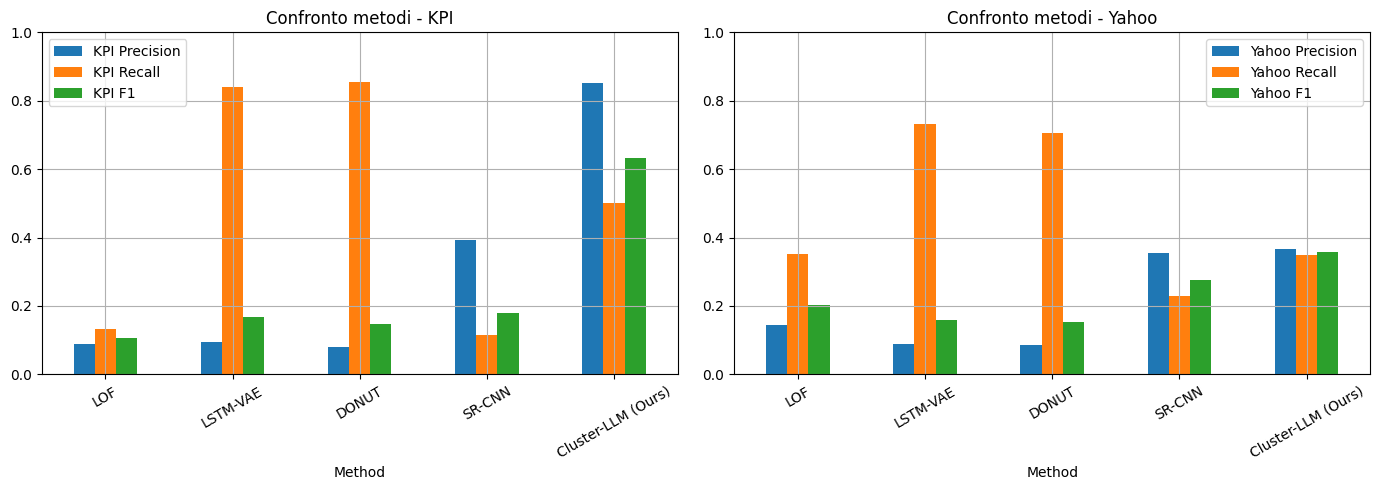

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dataset in zip(axes, ["KPI", "Yahoo"]):
    comparison_table[[f"{dataset} Precision", f"{dataset} Recall", f"{dataset} F1"]].plot(
        kind="bar", ax=ax, rot=30)
    ax.set_title(f"Confronto metodi - {dataset}")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Nel pannello **KPI** la barra *Precision* di Cluster-LLM (Ours) svetta nettamente sopra quella di tutti gli altri metodi (che restano sotto 0,4), mentre la sua barra *Recall* è nella media; SR-CNN mostra il pattern opposto per certi versi (recall basso, precision media). 

Nel pannello **Yahoo** le differenze sono meno marcate ma Cluster-LLM resta comunque il metodo con la barra Precision più alta. In entrambi i pannelli si nota visivamente il trade-off tipico di questi metodi: nessun metodo massimizza contemporaneamente tutte e tre le metriche, e la scelta del metodo migliore dipende da quanto costano, in un contesto reale, i falsi positivi rispetto ai falsi negativi.

### **Bibliografia**

B. Zhu, G. Xiong, M. Yuan, Z. Shen, F. Zhu, S. Chen, X. Dong, S. Liu, J. Chen, *Cluster-LLM: Adaptive Real-Time Time-Series Anomaly Detection Using LLMs*, CSIS-IAC 2025.

## **APPENDICE - Variante Usando Un LLM per il CoT**

### **1. EDA delle Serie di Esempio Usate nel Seguito**

Prima di implementare questa variante (in cui la pipeline CoT viene eseguita tramite LLM, ma solo sulle due serie d'esempio già selezionate nella Sezione 3.1, ovvero `example_key` per KPI e `yahoo_example_key` per Yahoo, e non su tutte le entità dei due dataset) è utile effettuare una EDA esclusivamente su tali due serie, analoga a quella già svolta nelle Sezioni 2.2-2.3 per l'intero dataset KPI e Yahoo. L'obiettivo è quello di verificare, prima di applicare il CoT via LLM, quante anomalie contengano queste due specifiche serie e come si posizionino rispetto alla media dell'intero dataset di appartenenza.

In [20]:
kpi_example_dict = {example_key: kpi_pp[example_key]}
yahoo_example_dict = {yahoo_example_key: yahoo_pp[yahoo_example_key]}

kpi_example_eda = eda_summary(kpi_example_dict, f"KPI - serie d'esempio ({example_key})")
yahoo_example_eda = eda_summary(yahoo_example_dict, f"Yahoo - serie d'esempio ({yahoo_example_key})")

display(kpi_example_eda)
display(yahoo_example_eda)

EDA - KPI - serie d'esempio (kpi_55f8b8b8-b659-38df-b3df-e4a5a8a54bc9)
Entita' (serie): 1
Punti totali: 146,204
Punti anomali totali: 3,867  (2.64% del dataset)
Valori mancanti totali: 0

EDA - Yahoo - serie d'esempio (real_53.csv)
Entita' (serie): 1
Punti totali: 1,461
Punti anomali totali: 17  (1.16% del dataset)
Valori mancanti totali: 0



,entita',n_punti,n_anomalie,%_anomalie,valore_min,valore_max,valori_mancanti
0,kpi_55f8b8b8-b659-38df-b3df-e4a5a8a54bc9,146204,3867,2.644934,0.0,288.81,0


,entita',n_punti,n_anomalie,%_anomalie,valore_min,valore_max,valori_mancanti
0,real_53.csv,1461,17,1.163587,20.975618,47.243282,0


La tabella riporta, per ciascuna delle due serie d'esempio, lo stesso tipo di statistiche già illustrate nella Sezione 2.2 (ossia numero di punti, numero e percentuale di anomalie, range dei valori, valori mancanti), calcolate però riutilizzando la medesima funzione `eda_summary` applicata questa volta a un dizionario avente una sola entità. In questo modo è possibile confrontare direttamente, nella cella di visualizzazione seguente, la percentuale di anomalie della singola serie d'esempio con quella media dell'intero dataset di appartenenza.

### **1.1 Visualizzazione EDA delle Serie di Esempio**

Il codice sottostante realizza due grafici affiancati, in modo analogo a quanto fatto nella Sezione 2.3: a sinistra è mostrato un confronto a barre a tre termini per ciascun dataset, ovvero la percentuale di anomalie riportata nel paper (Table III), quella dell'intero dataset qui caricato (come già calcolata in `kpi_eda`/`yahoo_eda`) e quella della singola serie scelta come esempio per i grafici di questa appendice, sia per KPI che per Yahoo; a destra, è riportata, al posto dell'istogramma per entità (non applicabile, essendoci una sola serie per dataset), la distribuzione dei valori grezzi delle due serie d'esempio, utile per avere un'idea della scala e della forma dei dati su cui verrà poi applicata la baseline CoT via LLM.

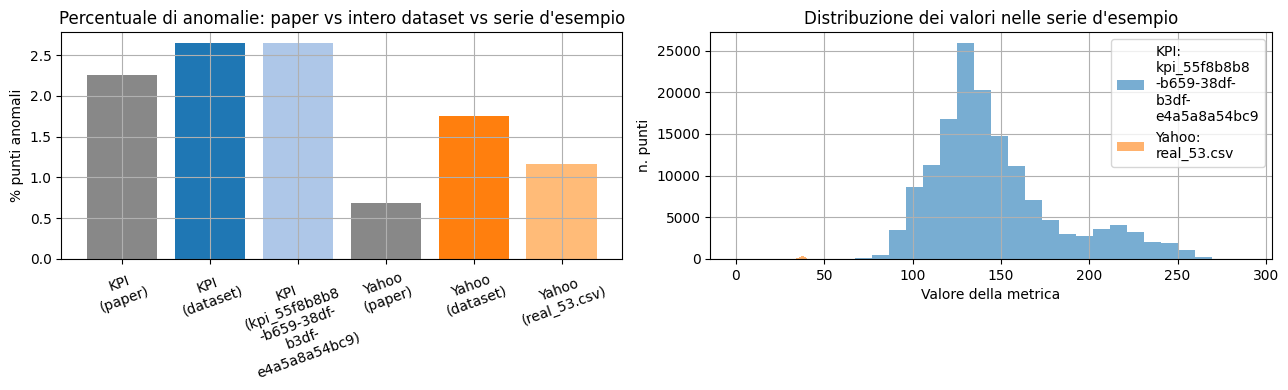

In [21]:
import textwrap

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

PAPER_KPI_PCT = 2.26      # % anomalie KPI riportata nel paper
PAPER_YAHOO_PCT = 0.68    # % anomalie Yahoo riportata nel paper

kpi_pct_dataset = 100 * kpi_eda["n_anomalie"].sum() / kpi_eda["n_punti"].sum()
yahoo_pct_dataset = 100 * yahoo_eda["n_anomalie"].sum() / yahoo_eda["n_punti"].sum()
kpi_pct_example = kpi_example_eda["%_anomalie"].iloc[0]
yahoo_pct_example = yahoo_example_eda["%_anomalie"].iloc[0]

WRAP_WIDTH = 12  # caratteri max per riga prima di andare a capo

def wrap_name(name: str, width: int = WRAP_WIDTH) -> str:
    return "\n".join(textwrap.wrap(name, width=width)) if len(name) > width else name

labels = [
    "KPI\n(paper)", "KPI\n(dataset)", f"KPI\n({wrap_name(example_key)})",
    "Yahoo\n(paper)", "Yahoo\n(dataset)", f"Yahoo\n({wrap_name(yahoo_example_key)})",
]
values = [
    PAPER_KPI_PCT, kpi_pct_dataset, kpi_pct_example,
    PAPER_YAHOO_PCT, yahoo_pct_dataset, yahoo_pct_example,
]
colors = ["#888888", "#1f77b4", "#aec7e8", "#888888", "#ff7f0e", "#ffbb78"]

axes[0].bar(labels, values, color=colors)
axes[0].set_ylabel("% punti anomali")
axes[0].set_title("Percentuale di anomalie: paper vs intero dataset vs serie d'esempio")
axes[0].tick_params(axis="x", rotation=20)

axes[1].hist(kpi_pp[example_key]["value"], bins=30, alpha=0.6,
             label=f"KPI:\n{wrap_name(example_key)}")
axes[1].hist(yahoo_pp[yahoo_example_key]["value"], bins=30, alpha=0.6,
             label=f"Yahoo:\n{wrap_name(yahoo_example_key)}")
axes[1].set_xlabel("Valore della metrica")
axes[1].set_ylabel("n. punti")
axes[1].set_title("Distribuzione dei valori nelle serie d'esempio")
axes[1].legend()

plt.tight_layout()
plt.show()

Nel pannello di sinistra, per ciascun dataset sono ora confrontate tre barre: quella grigia riporta la percentuale di anomalie del paper (Table III), quella intermedia (blu per KPI, arancione per Yahoo) la percentuale misurata sull'intero dataset qui caricato (già discussa nella Sezione 2.2, ossia 2,65% su KPI e 1,76% su Yahoo), e quella più chiara la percentuale della singola serie scelta come esempio (`example_key` per KPI, `yahoo_example_key` per Yahoo). Confrontando le tre barre si osserva sia quanto il dataset qui caricato si discosti dal paper, sia quanto la singola serie d'esempio sia più o meno critica della media del proprio dataset di appartenenza: uno scostamento marcato di quest'ultima barra indica che la serie scelta è più (o meno) anomala della media, informazione utile per interpretare correttamente i risultati di questa appendice, che si basano solo su questa serie e non sull'intero dataset. Nel pannello di destra l'istogramma dei valori grezzi permette di verificare visivamente su quale scala numerica opererà il CoT via LLM, così da poter valutare sin da subito la coerenza delle baseline stimate dal LLM rispetto all'effettivo range dei dati.

### **2. Implementazione con Ollama (deepseek-r1:8b) ossia Realizzando un CoT Reale via LLM**

Nella parte precedente (Sezione 5), i tre step del Chain-of-Thought sono stati implementati mediante una logica statistica deterministica equivalente, senza alcuna chiamata a un LLM esterno. In questa sezione, invece, si implementa l'approccio in maniera analoga a quanto descritto nel paper di riferimento. Nello specifico, le tre chiamate CoT per cluster (ossia z-score baseline, Gaussian fitting, fusione) vengono inviate a un LLM locale servito tramite **Ollama**, usando lo stesso modello impiegato nell'articolo di riferimento (ossia **deepseek-r1:8b**).

I requisiti per eseguire questa sezione con un vero LLM sono:
- avere [Ollama](https://ollama.com) installato e in esecuzione (`ollama serve`), raggiungibile su `http://localhost:11434`;
- avere il modello scaricato con `ollama pull deepseek-r1:8b`.

Se questi requisiti non sono soddisfatti, ogni singola chiamata ricade automaticamente sulla formulazione deterministica equivalente della Sezione 5, con un avviso stampato a schermo.

### **2.1 Client Ollama e Parsing dell'Output**

La cella seguente definisce `ollama_generate`, che invoca l'endpoint REST `/api/generate` di Ollama e restituisce l'oggetto JSON contenuto nella risposta del modello. Poiché **deepseek-r1** è un modello reasoning che antepone alla risposta vera e propria un blocco `<think>...</think>` (e talvolta racchiude il JSON in un blocco Markdown), `_extract_json` rimuove prima il blocco di ragionamento e poi isola il primo oggetto `{...}` valido, prima del parsing. `_ollama_is_available` verifica all'avvio, con un timeout breve, se il server è raggiungibile e se il modello richiesto è già stato scaricato, impostando il flag globale `OLLAMA_AVAILABLE` usato da tutte le celle successive.

In [22]:
import json
import re

try:
    import requests
    REQUESTS_OK = True
except Exception:
    REQUESTS_OK = False

OLLAMA_HOST = "http://localhost:11434"
OLLAMA_MODEL = "deepseek-r1:8b"
OLLAMA_TIMEOUT = 900
OLLAMA_MAX_RETRIES = 3


def _ollama_is_available(host=OLLAMA_HOST, model=OLLAMA_MODEL, timeout=3) -> bool:
    if not REQUESTS_OK:
        print("  [WARN] libreria 'requests' non disponibile (pip install requests).")
        return False
    try:
        r = requests.get(f"{host}/api/tags", timeout=timeout)
        r.raise_for_status()
        names = [m.get("name", "") for m in r.json().get("models", [])]
        available = any(model.split(":")[0] in n for n in names)
        if not available:
            print(f"  [WARN] server Ollama raggiungibile ma modello '{model}' non trovato tra {names}.")
        return available
    except Exception as e:
        print(f"  [WARN] server Ollama non raggiungibile su {host} ({e}).")
        return False


OLLAMA_AVAILABLE = _ollama_is_available()
print(f"Ollama disponibile e modello '{OLLAMA_MODEL}' pronto: {OLLAMA_AVAILABLE}")
if not OLLAMA_AVAILABLE:
    print("  -> le celle seguenti ricadranno automaticamente sulla logica statistica deterministica")
    print("     della Sezione 5 ogni volta che una chiamata LLM fallisce o non e' disponibile,")
    print("     cosi' l'intero notebook resta eseguibile end-to-end anche senza Ollama installato.")


def _strip_think(text: str) -> str:
    # deepseek-r1 è un modello "reasoning": antepone un blocco <think>...</think>
    # alla risposta vera e propria, che va scartato prima del parsing JSON
    return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()


DEBUG_LLM_RAW = True


def _find_first_balanced_json(cleaned: str):
    start = cleaned.find("{")
    if start == -1:
        return None
    depth = 0
    in_string = False
    escape = False
    for i in range(start, len(cleaned)):
        ch = cleaned[i]
        if in_string:
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == '"':
                in_string = False
        else:
            if ch == '"':
                in_string = True
            elif ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    return cleaned[start:i + 1]
    return None  # nessuna graffa di chiusura bilanciata trovata (JSON troncato)


def _extract_json(text: str):
    stripped = _strip_think(text)
    cleaned = re.sub(r"```(?:json)?", "", stripped).strip()
    candidate = _find_first_balanced_json(cleaned)
    if candidate is None:
        if DEBUG_LLM_RAW:
            think_len = len(text) - len(stripped)
            print(f"    [DEBUG] nessun blocco JSON bilanciato trovato. Risposta grezza ({len(text)} caratteri, "
                  f"di cui ~{think_len} nel blocco <think>): {cleaned[:300]!r}")
        raise ValueError("nessun blocco JSON bilanciato trovato nella risposta del modello")
    try:
        return json.loads(candidate)
    except json.JSONDecodeError as e:
        if DEBUG_LLM_RAW:
            print(f"    [DEBUG] blocco JSON individuato ma non parsabile ({e}): {candidate[:300]!r}")
        raise


def ollama_generate(prompt: str, model: str = OLLAMA_MODEL, host: str = OLLAMA_HOST,
                     timeout: int = OLLAMA_TIMEOUT, max_retries: int = OLLAMA_MAX_RETRIES) -> dict:
    # Chiama l'endpoint /api/generate di Ollama e restituisce il JSON parsato dalla risposta del modello,
    # ritentando fino a max_retries volte in caso di errore di rete o di parsing.
    last_err = None
    for attempt in range(max_retries + 1):
        try:
            r = requests.post(
                f"{host}/api/generate",
                json={"model": model, "prompt": prompt, "stream": False,
                      "format": "json",  # forza Ollama a vincolare l'output a JSON sintatticamente valido
                      "options": {
                          "temperature": 0.1,
                          "num_ctx": 8192,
                          "num_predict": -1,
                      }},
                timeout=timeout,
            )
            r.raise_for_status()
            raw_text = r.json().get("response", "")
            return _extract_json(raw_text)
        except Exception as e:
            last_err = e
            if DEBUG_LLM_RAW:
                print(f"    [DEBUG] tentativo {attempt + 1}/{max_retries + 1} fallito: {type(e).__name__}: {e}")
    raise RuntimeError(f"chiamata Ollama fallita dopo {max_retries + 1} tentativi: {last_err}")

Ollama disponibile e modello 'deepseek-r1:8b' pronto: True


L'esecuzione di questa cella stampa a schermo un avviso indicante se il server Ollama è raggiungibile e se il modello `deepseek-r1:8b` è già stato scaricato (flag `OLLAMA_AVAILABLE`), oltre a rendere disponibile la funzione `ollama_generate` usata da tutte le celle successive per interrogare il LLM. Se il flag risulta `False` (ossia server non attivo o modello non scaricato), ogni chiamata successiva ricadrà automaticamente sulla logica statistica deterministica già descritta e usata nella Sezione 5, riportando un messaggio di fallback stampato a schermo per ciascuna occorrenza.

### **2.2 Prompt CoT a 3 Step via LLM**

Le funzioni seguenti replicano i tre prompt illustrati nell'articolo di riferimento: **Step 1** (z-score sulla serie giornaliera del cluster), **Step 2** (fit Gaussiano su una finestra scorrevole di ±5 minuti) e **Step 3** (fusione). Interrogare il LLM una volta per ciascuno dei 1440 minuti del giorno sarebbe computazionalmente non fattibile con un modello da 8B eseguito localmente; coerentemente con l'articolo (in cui ogni step produce un unico output per l'intero cluster), la baseline viene quindi stimata dall'LLM a **risoluzione oraria ridotta** (6 punti rappresentativi, uno ogni 4 ore `LLM_HOUR_BINS`) e successivamente interpolata sull'intero asse dei minuti, esattamente come la baseline deterministica della Sezione 5 in modo tale da rendere le due pipeline direttamente confrontabili.

In [23]:
LLM_HOUR_BINS = np.arange(0, 1440,  240)

Z_MULT_MIN = 1.0
Z_MULT_MAX = 4.0


def _llm_step1_zscore(daily_values: np.ndarray) -> Tuple[float, float]:
    # Step 1 del CoT (Fig. 3): 'Use z-score to calculate upper and lower bounds'
    stats = {
        "mean": float(np.nanmean(daily_values)),
        "std": float(np.nanstd(daily_values)),
        "min": float(np.nanmin(daily_values)),
        "max": float(np.nanmax(daily_values)),
        "n_points": int(len(daily_values)),
    }
    prompt = (
        "You are a time-series anomaly detection assistant.\n"
        "Step 1: choose a z-score multiplier k to compute the upper and lower baseline bounds for "
        "this cluster of daily time-series data, using the rule upper = mean + k*std, "
        "lower = mean - k*std.\n"
        f"Input statistics: {json.dumps(stats)}\n"
        f"Typical values of k range between {Z_MULT_MIN} and {Z_MULT_MAX}, with k=3.0 as a common "
        "default (~99.7%% coverage band for a normal distribution). Use a larger k if the data looks "
        "noisy or highly variable, a smaller k if it looks very stable.\n"
        "Respond with ONLY a JSON object of the form {\"k\": <float>} and nothing else. "
        "Do NOT compute upper or lower yourself -- only return k."
    )
    out = ollama_generate(prompt)
    try:
        k = float(out["k"])
    except (TypeError, ValueError, KeyError) as e:
        raise ValueError(f"'k' mancante o non numerico nella risposta dell'LLM (Step 1): {out}") from e
    k = min(max(k, Z_MULT_MIN), Z_MULT_MAX)
    mu, sigma = stats["mean"], stats["std"]
    return mu - k * sigma, mu + k * sigma


def _parse_hourly_z_response(out: dict, min_valid_fraction: float = 0.0,
                              z_min: float = Z_MULT_MIN, z_max: float = Z_MULT_MAX) -> np.ndarray:
    k_by_bin: Dict[int, float] = {}

    if isinstance(out, dict) and "k" in out and isinstance(out["k"], list):
        k_list = out["k"]
        if len(k_list) == len(LLM_HOUR_BINS):
            for hb, k in zip(LLM_HOUR_BINS, k_list):
                try:
                    kv = float(k)
                except (TypeError, ValueError):
                    continue
                if z_min <= kv <= z_max:
                    k_by_bin[int(hb)] = kv
    else:
        for hb in LLM_HOUR_BINS:
            entry = out.get(str(int(hb))) if isinstance(out, dict) else None
            if entry is None and isinstance(out, dict):
                entry = out.get(int(hb))
            k_val = None
            if isinstance(entry, dict) and "k" in entry:
                k_val = entry["k"]
            elif isinstance(entry, (int, float, str)):
                k_val = entry
            if k_val is None:
                continue
            try:
                kv = float(k_val)
            except (TypeError, ValueError):
                continue
            if not (z_min <= kv <= z_max):
                continue
            k_by_bin[int(hb)] = kv

    n_valid = len(k_by_bin)
    if n_valid < max(2, int(min_valid_fraction * len(LLM_HOUR_BINS))):
        if DEBUG_LLM_RAW:
            print(f"    [DEBUG] JSON valido ma solo {n_valid}/{len(LLM_HOUR_BINS)} valori di k "
                  f"utilizzabili (attesi: {[int(hb) for hb in LLM_HOUR_BINS]}, range [{z_min}, {z_max}]). "
                  f"Oggetto ricevuto: {json.dumps(out)[:500]}")
        raise ValueError(
            f"solo {n_valid}/{len(LLM_HOUR_BINS)} valori di k validi nella risposta dell'LLM"
        )

    known_bins = np.array(sorted(k_by_bin.keys()), dtype=float)
    k_known = np.array([k_by_bin[int(b)] for b in known_bins])
    return np.interp(LLM_HOUR_BINS, known_bins, k_known, period=1440)


def _llm_step2_gaussian(minute_index: np.ndarray, pooled_values: Dict[int, np.ndarray],
                         window: int = GAUSSIAN_WINDOW_MIN) -> Tuple[np.ndarray, np.ndarray]:
    # Step 2 del CoT (Fig. 3): finestra scorrevole +-5 minuti, fit Gaussiano locale, a risoluzione oraria
    minutes = np.asarray(sorted(minute_index))
    local_stats = []
    for hb in LLM_HOUR_BINS:
        m = minutes[np.argmin(np.abs(minutes - hb))]
        sel = minutes[(minutes >= m - window) & (minutes <= m + window)]
        vals = np.concatenate([pooled_values[mm] for mm in sel])
        local_stats.append({"hour_bin": int(hb),
                             "mean": float(np.nanmean(vals)), "std": float(np.nanstd(vals))})
    hour_bins_list = [int(hb) for hb in LLM_HOUR_BINS]
    prompt = (
        "You are a time-series anomaly detection assistant.\n"
        "Step 2: for each hourly bin below you are given the mean and standard deviation of a local "
        "+/-5 minute Gaussian-window fit. For each bin, choose a z-score multiplier k to be used as "
        "upper = mean + k*std, lower = mean - k*std (do NOT compute upper/lower yourself).\n"
        f"Input ({len(LLM_HOUR_BINS)} hourly bins): {json.dumps(local_stats)}\n"
        f"The hour_bin values you must cover are exactly: {json.dumps(hour_bins_list)}.\n"
        f"Typical k values range between {Z_MULT_MIN} and {Z_MULT_MAX} (k=3.0 is a common default). "
        "Use a larger k for bins you judge noisier/more variable, a smaller k for very stable bins.\n"
        "Respond with ONLY a JSON object mapping EACH hour_bin value (as a string key) to its k, "
        "in the exact form {\"0\": {\"k\": <float>}, \"240\": {\"k\": <float>}, ...}. Include all "
        + str(len(LLM_HOUR_BINS)) + " keys listed above, exactly one entry per hour_bin, and no other "
        "keys or text."
    )
    out = ollama_generate(prompt)
    k_full = _parse_hourly_z_response(out)
    means = np.array([s["mean"] for s in local_stats])
    stds = np.array([s["std"] for s in local_stats])
    return means - k_full * stds, means + k_full * stds


def _llm_step3_fuse(low1: float, up1: float, low2: np.ndarray, up2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    # Step 3 del CoT (Fig. 3): 'fuse the two sets of baselines into one final result'
    hour_bins_list = [int(hb) for hb in LLM_HOUR_BINS]
    step2_per_bin = {str(hb): {"upper": float(u), "lower": float(l)}
                      for hb, u, l in zip(hour_bins_list, up2.tolist(), low2.tolist())}
    prompt = (
        "You are a time-series anomaly detection assistant.\n"
        "Step 3: fuse the Step-1 baseline (a single daily z-score bound) with the Step-2 baseline "
        "(hourly Gaussian-window bounds) into one final adaptive baseline.\n"
        f"Step 1 output: {json.dumps({'upper': up1, 'lower': low1})}\n"
        f"Step 2 output (per hourly bin): {json.dumps(step2_per_bin)}\n"
        "Choose a single fusion weight w in [0, 1]: the final bound at every hour will be computed as "
        "w * step2_bound + (1 - w) * step1_bound, for both upper and lower (do NOT compute the fused "
        "bounds yourself -- only return w). Use w=0.5 for equal weight between the two baselines (the "
        "default suggested by the method), move w toward 1 if the hourly Step-2 pattern looks more "
        "reliable, toward 0 if the single daily Step-1 bound looks more reliable.\n"
        "Respond with ONLY a JSON object of the form {\"w\": <float between 0 and 1>} and nothing else."
    )
    out = ollama_generate(prompt)
    try:
        w = float(out["w"])
    except (TypeError, ValueError, KeyError) as e:
        raise ValueError(f"'w' mancante o non numerico nella risposta dell'LLM (Step 3): {out}") from e
    if not (0.0 <= w <= 1.0):
        if DEBUG_LLM_RAW:
            print(f"    [DEBUG] peso di fusione w={w} fuori range [0,1], applico clip.")
        w = min(max(w, 0.0), 1.0)
    return w * low2 + (1 - w) * low1, w * up2 + (1 - w) * up1

### **2.3 Pipeline CoT Completa via LLM (con Fallback Automatico)**

La funzione `llm_cot_infer_cluster_baseline` incapsula i tre step precedenti in un blocco `try/except`: se una qualunque chiamata fallisce, la funzione ricade sulla formulazione deterministica equivalente già definite nella Sezione 5 (`zscore_baseline`, `gaussian_window_baseline`, `fuse_baselines`), incrementando il contatore globale `LLM_CALL_STATS["fallback"]`.

In [24]:
LLM_CALL_STATS = {"ok": 0, "fallback": 0}


def llm_cot_infer_cluster_baseline(cluster_df: pd.DataFrame) -> Dict:
    daily_values = cluster_df["value_smooth"].values
    minute_of_day = cluster_df["minute_of_day"].values
    pooled = {m: cluster_df.loc[cluster_df["minute_of_day"] == m, "value_smooth"].values
              for m in np.unique(minute_of_day)}

    try:
        if not OLLAMA_AVAILABLE:
            raise RuntimeError("Ollama non disponibile")
        low1, up1 = _llm_step1_zscore(daily_values)
        low2, up2 = _llm_step2_gaussian(minute_of_day, pooled)
        low3, up3 = _llm_step3_fuse(low1, up1, low2, up2)

        LLM_CALL_STATS["ok"] += 1
    except Exception as e:
        LLM_CALL_STATS["fallback"] += 1
        print(f"  [LLM FALLBACK] cluster non riuscito via Ollama ({type(e).__name__}: {e}) "
              f"-> uso la baseline deterministica di riserva per questo cluster. "
              f"(Impostare DEBUG_LLM_RAW=True, gia' fatto di default, per vedere la risposta grezza "
              f"del modello nelle righe [DEBUG] sopra.)")
        low1, up1 = zscore_baseline(daily_values)
        low2, up2 = gaussian_window_baseline(np.unique(minute_of_day), pooled)
        low3, up3 = fuse_baselines(low1, up1, low2, up2)
        minute_out = np.asarray(sorted(np.unique(minute_of_day)))
        return {"lower": low3, "upper": up3, "minute_index": minute_out}

    minute_out = np.asarray(sorted(np.unique(minute_of_day)))
    lower = np.interp(minute_out, LLM_HOUR_BINS, low3, period=1440)
    upper = np.interp(minute_out, LLM_HOUR_BINS, up3, period=1440)
    return {"lower": lower, "upper": upper, "minute_index": minute_out}


def build_cluster_profiles_llm(df: pd.DataFrame) -> Dict[int, ClusterProfile]:
    profiles = {}
    n_days_total = df["date"].nunique()
    for c, g in df.groupby("cluster"):
        n_days_c = g["date"].nunique()
        confidence = n_days_c / n_days_total
        cot_result = llm_cot_infer_cluster_baseline(g)
        profiles[c] = ClusterProfile(
            cluster_id=c, lower=cot_result["lower"], upper=cot_result["upper"],
            confidence=confidence, minute_index=cot_result["minute_index"],
        )
    return profiles

### **2.4 Visualizzazione Grafica su una Serie di Esempio (sia per KPI che per Yahoo) delle Baseline via LLM**

Come nella Sezione 5.2, si costruiscono i profili dei cluster (questa volta con `build_cluster_profiles_llm`) per le stesse serie d'esempio usate in tutto il notebook (`example_key` per KPI, `yahoo_example_key` per Yahoo) e si visualizza la baseline adattiva risultante con la stessa funzione `plot_fig4` già definita nella Sezione 5.2.

KPI (Ollama deepseek-r1:8b)
Cluster 0: confidence=0.276, n_punti_baseline=1440
Cluster 1: confidence=0.724, n_punti_baseline=1440
Yahoo (Ollama deepseek-r1:8b)
Cluster 0: confidence=0.661, n_punti_baseline=24
Cluster 1: confidence=0.016, n_punti_baseline=9
Cluster 2: confidence=0.016, n_punti_baseline=12
Cluster 3: confidence=0.016, n_punti_baseline=24
Cluster 4: confidence=0.016, n_punti_baseline=24
Cluster 5: confidence=0.274, n_punti_baseline=24

Chiamate LLM riuscite finora: 8, fallback deterministico: 0


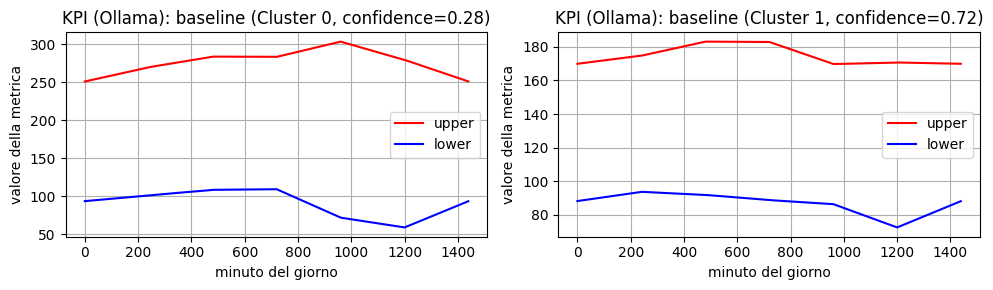

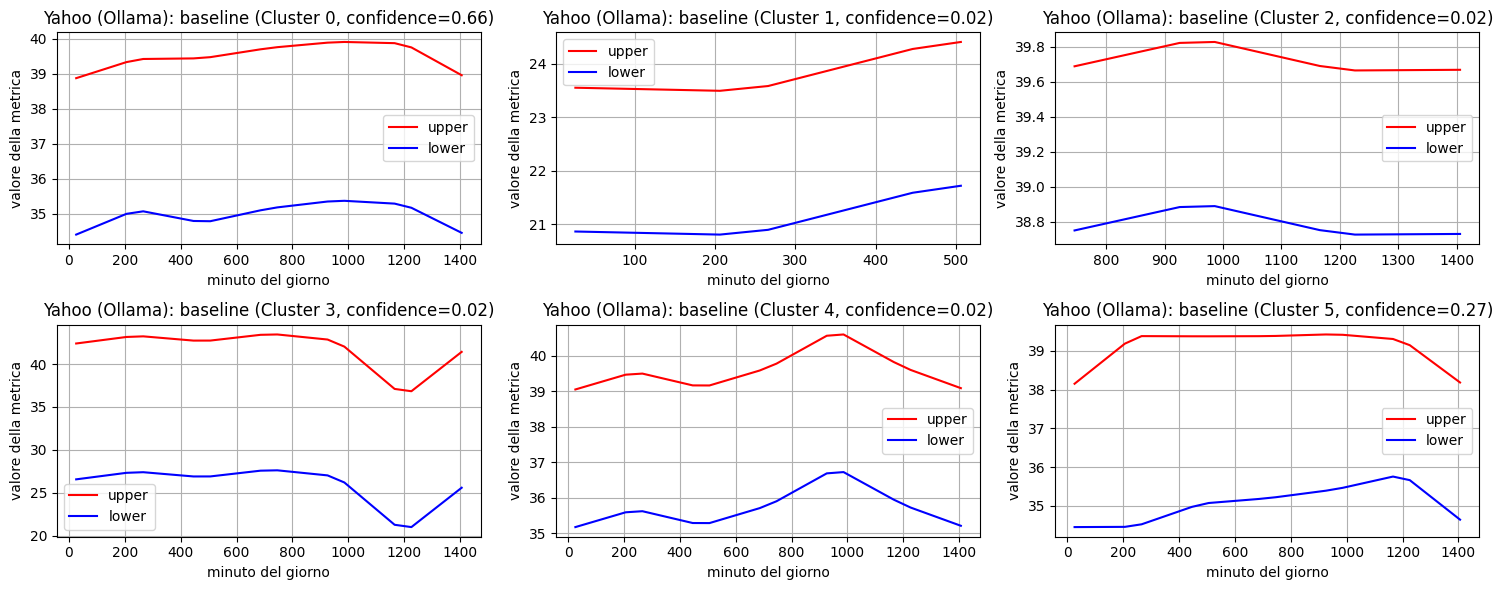

In [25]:
llm_cluster_profiles = build_cluster_profiles_llm(kpi_pp[example_key])
llm_yahoo_cluster_profiles = build_cluster_profiles_llm(yahoo_pp[yahoo_example_key])

print("KPI (Ollama deepseek-r1:8b)")
for cid, prof in llm_cluster_profiles.items():
    print(f"Cluster {cid}: confidence={prof.confidence:.3f}, n_punti_baseline={len(prof.lower)}")
print("Yahoo (Ollama deepseek-r1:8b)")
for cid, prof in llm_yahoo_cluster_profiles.items():
    print(f"Cluster {cid}: confidence={prof.confidence:.3f}, n_punti_baseline={len(prof.lower)}")

print(f"\nChiamate LLM riuscite finora: {LLM_CALL_STATS['ok']}, fallback deterministico: {LLM_CALL_STATS['fallback']}")

plot_fig4(llm_cluster_profiles, "KPI (Ollama)")
plot_fig4(llm_yahoo_cluster_profiles, "Yahoo (Ollama)")

L'esecuzione produce, per ciascuna serie d'esempio (KPI e Yahoo), l'elenco dei cluster individuati con il relativo confidence score (analogo a quanto già illustrato nella Sezione 5.2, ma in questo caso le baseline superiore/inferiore di ciascun cluster sono stimate dal LLM anziché in modo deterministico) e i due grafici prodotti da `plot_fig4` con la baseline adattiva risultante. Il conteggio finale di `LLM_CALL_STATS` (chiamate riuscite vs fallback) permette di verificare se le baseline mostrate provengono realmente dal modello `deepseek-r1:8b` oppure, in caso di fallback, dalla stessa logica statistica già approfondita nella Sezione 5.

### **2.5 Algoritmo di Real-Time Anomaly Detection sulla Serie di Esempio**

Viene applicata la funzione `detect_anomalies` (della Sezione 5.3) usando questa volta i profili stimati dal LLM e si visualizza il risultato con una funzione di plotting analoga a `plot_fig5` (della Sezione 5.4), qui ridefinita come `plot_fig5_llm` per scrivere le predizioni in colonne separate (`pred_llm`/`score_llm`) e non sovrascrivere i risultati deterministici della Sezione 5 già presenti negli stessi DataFrame.

[KPI] Latenza rilevamento (esempio, Ollama): 0.006s, anomalie rilevate: 34 / 146204 punti, anomalie vere: 3867
[Yahoo] Latenza rilevamento (esempio, Ollama): 0.001s, anomalie rilevate: 72 / 1461 punti, anomalie vere: 17


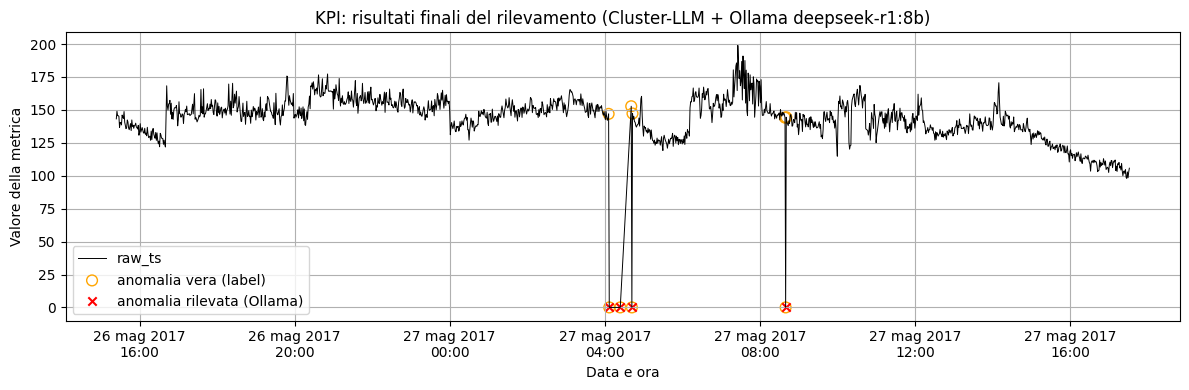

[KPI] In questa finestra: 9 anomalie vere, 4 anomalie rilevate.


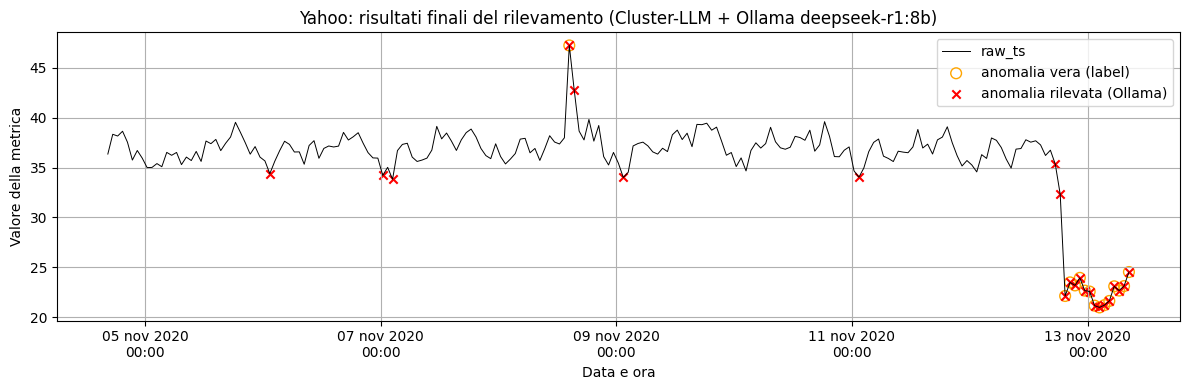

[Yahoo] In questa finestra: 15 anomalie vere, 23 anomalie rilevate.


In [26]:
def _run_and_report_llm(pp_dict, key, profiles, dataset_name):
    t0 = time.time()
    preds, scores = detect_anomalies(pp_dict[key], profiles, threshold=DETECTION_THRESHOLD)
    latency = time.time() - t0
    pp_dict[key]["pred_llm"] = preds
    pp_dict[key]["score_llm"] = scores
    n_true = int(pp_dict[key]["label"].fillna(0).sum())
    print(f"[{dataset_name}] Latenza rilevamento (esempio, Ollama): {latency:.3f}s, "
          f"anomalie rilevate: {preds.sum()} / {len(preds)} punti, anomalie vere: {n_true}")
    return preds, scores


def plot_fig5_llm(pp_dict, key, dataset_name, window=750):
    full = pp_dict[key]
    label = full["label"].fillna(0)
    tp_idx = full.index[(full["pred_llm"] == 1) & (label == 1)]
    any_idx = full.index[(full["pred_llm"] == 1) | (label == 1)]
    if len(tp_idx) > 0:
        center = tp_idx[len(tp_idx) // 2]
    elif len(any_idx) > 0:
        center = any_idx[len(any_idx) // 2]
    else:
        center = full.index[len(full) // 2]
    start = max(0, int(center) - window)
    sub = full.iloc[start:start + 2 * window]

    x = pd.to_datetime(sub[["year", "month", "day", "hour", "minute"]])
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, sub["value"], color="black", lw=0.7, label="raw_ts")
    true_anom = sub[sub["label"].fillna(0) == 1]
    pred_anom = sub[sub["pred_llm"] == 1]
    if len(true_anom):
        x_true = pd.to_datetime(true_anom[["year", "month", "day", "hour", "minute"]])
        ax.scatter(x_true, true_anom["value"], color="orange", marker="o",
                   facecolors="none", s=60, label="anomalia vera (label)")
    x_pred = pd.to_datetime(pred_anom[["year", "month", "day", "hour", "minute"]])
    ax.scatter(x_pred, pred_anom["value"], color="red", marker="x", label="anomalia rilevata (Ollama)")
    ax.legend()
    ax.set_title(f"{dataset_name}: risultati finali del rilevamento (Cluster-LLM + Ollama deepseek-r1:8b)")
    ax.set_xlabel("Data e ora")
    ax.set_ylabel("Valore della metrica")

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=8))
    ax.xaxis.set_major_formatter(_formatta_data_ora)
    fig.autofmt_xdate(rotation=0, ha="center")

    plt.tight_layout()
    plt.show()
    print(f"[{dataset_name}] In questa finestra: {len(true_anom)} anomalie vere, {len(pred_anom)} anomalie rilevate.")


_run_and_report_llm(kpi_pp, example_key, llm_cluster_profiles, "KPI")
_run_and_report_llm(yahoo_pp, yahoo_example_key, llm_yahoo_cluster_profiles, "Yahoo")

plot_fig5_llm(kpi_pp, example_key, "KPI")
plot_fig5_llm(yahoo_pp, yahoo_example_key, "Yahoo", window=200)

L'esecuzione stampa, per KPI e Yahoo, la latenza di rilevamento sulla serie d'esempio e il conteggio di anomalie rilevate rispetto a quelle vere (scritte nelle colonne `pred_llm`/`score_llm`, per non sovrascrivere i risultati deterministici della Sezione 5). Tale esecuzione mostra anche i due grafici prodotti da `plot_fig5_llm` (contenenti la curva grezza in nero, le anomalie vere indicate con cerchi arancioni e le anomalie rilevate dal modello segnate con x rosse). Confrontando questi due grafici con quelli analoghi della Sezione 5.4 è possibile valutare visivamente quanto le baseline stimate dal LLM portino a un comportamento di detection diverso rispetto a quello che si ha nel caso della variante deterministica.

### **2.6 Pipeline End-to-End con Ollama su Serie di esempio**

La funzione `run_cluster_llm_ollama` esegue l'intera pipeline (preprocessing $\rightarrow$ clustering $\rightarrow$ **CoT via LLM** $\rightarrow$ detection) su una singola serie. La funzione `run_cluster_llm_on_dataset_ollama` la applica a più entità, concatenando le predizioni prima di calcolare Precision/Recall/F1 aggregati, esattamente come effettuato da `run_cluster_llm_on_dataset`.

Con un modello da 8B eseguito localmente, ogni cluster richiede 3 chiamate al LLM: su tutte le 29+67 = 96 entità dei due dataset ciò significa centinaia di chiamate, che su hardware consumer possono richiedere da decine di minuti a diverse ore (a seconda della GPU/CPU disponibile). Per mantenere la cella eseguibile in tempi ragionevoli di default, `OLLAMA_SUBSAMPLE_N` limita il numero di entità per dataset su cui viene eseguita la pipeline via LLM; impostarlo a `None` per replicare i risultati del paper sull'intero dataset.

In [27]:
def run_cluster_llm_ollama(raw_df: pd.DataFrame, threshold: float = DETECTION_THRESHOLD) -> Dict:
    t0 = time.time()
    df = preprocess_series(raw_df)
    df, kmeans_model, feat_table = cluster_series(df)
    profiles = build_cluster_profiles_llm(df)
    preds, scores = detect_anomalies(df, profiles, threshold=threshold)
    df["pred"] = preds
    df["score"] = scores
    elapsed = time.time() - t0
    metrics = evaluate(df["label"].fillna(0).values, preds)
    metrics["time_s"] = elapsed
    metrics["n_clusters"] = kmeans_model.n_clusters
    return {"metrics": metrics, "df": df, "profiles": profiles}


def run_cluster_llm_on_dataset_ollama(data_dict: Dict[str, pd.DataFrame], threshold: float = DETECTION_THRESHOLD,
                                       subsample_n=None) -> Dict[str, float]:
    items = list(data_dict.items())
    if subsample_n is not None:
        rng = random.Random(48)
        items = rng.sample(items, k=min(subsample_n, len(items)))
    all_true, all_pred = [], []
    total_time = 0.0
    for name, raw_df in items:
        res = run_cluster_llm_ollama(raw_df, threshold=threshold)
        all_true.append(res["df"]["label"].fillna(0).values)
        all_pred.append(res["df"]["pred"].values)
        total_time += res["metrics"]["time_s"]
        print(f"  [{name}] fatto in {res['metrics']['time_s']:.1f}s "
              f"(precision={res['metrics']['precision']:.3f}, recall={res['metrics']['recall']:.3f})")
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    metrics = evaluate(y_true, y_pred)
    metrics["time_s"] = total_time
    metrics["n_entita"] = len(items)
    return metrics


# RUN_ON_FULL_DATASET = False (default): esegue la pipeline via Ollama solo sulle due serie d'esempio
#   già selezionate nella Sezione 1 dell'Appendice (example_key per KPI, yahoo_example_key per Yahoo),
#   in modo da restare eseguibile in tempi ragionevoli.
# RUN_ON_FULL_DATASET = True: replica la Table IV del paper eseguendo la pipeline su tutte le 29+67
#   entità dei due dataset. Con un modello da 8B locale (3 chiamate LLM per cluster) questo può
#   richiedere da decine di minuti a diverse ore, a seconda della GPU/CPU disponibile.
RUN_ON_FULL_DATASET = False

# OLLAMA_SUBSAMPLE_N: usato solo se RUN_ON_FULL_DATASET = True, per limitare il numero di entità per
#   dataset su cui viene eseguita la pipeline via LLM (None = intero dataset, come nella Table IV del paper).
OLLAMA_SUBSAMPLE_N = None

if RUN_ON_FULL_DATASET:
    kpi_target_data = kpi_data
    yahoo_target_data = yahoo_data
    kpi_subsample_n = OLLAMA_SUBSAMPLE_N
    yahoo_subsample_n = OLLAMA_SUBSAMPLE_N
    print(f"Esecuzione pipeline Cluster-LLM + Ollama su "
          f"{OLLAMA_SUBSAMPLE_N if OLLAMA_SUBSAMPLE_N is not None else 'tutte le'} entita' per dataset...")
else:
    # Si riutilizzano le stesse due serie d'esempio già selezionate nella Sezione 1 dell'Appendice
    # (example_key per KPI, yahoo_example_key per Yahoo) invece dell'intero dataset
    kpi_target_data = {example_key: kpi_data[example_key]}
    yahoo_target_data = {yahoo_example_key: yahoo_data[yahoo_example_key]}
    kpi_subsample_n = None
    yahoo_subsample_n = None
    print(f"Esecuzione pipeline Cluster-LLM + Ollama sulla serie d'esempio KPI ({example_key}) "
          f"e sulla serie d'esempio Yahoo ({yahoo_example_key})...")

cluster_llm_ollama_kpi = run_cluster_llm_on_dataset_ollama(kpi_target_data, subsample_n=kpi_subsample_n)
cluster_llm_ollama_yahoo = run_cluster_llm_on_dataset_ollama(yahoo_target_data, subsample_n=yahoo_subsample_n)

print("\nCluster-LLM + Ollama (deepseek-r1:8b) su KPI:", cluster_llm_ollama_kpi)
print("Cluster-LLM + Ollama (deepseek-r1:8b) su Yahoo:", cluster_llm_ollama_yahoo)
print(f"\nChiamate LLM totali riuscite: {LLM_CALL_STATS['ok']}, fallback deterministico: {LLM_CALL_STATS['fallback']}")
print()
print("Tabella IV del paper (KPI): F1=0.642, Precision=0.985, Recall=0.477, Time=283s")
print("Tabella del paper (Yahoo): F1=0.537, Precision=0.885, Recall=0.389, Time=23s")

Esecuzione pipeline Cluster-LLM + Ollama sulla serie d'esempio KPI (kpi_55f8b8b8-b659-38df-b3df-e4a5a8a54bc9) e sulla serie d'esempio Yahoo (real_53.csv)...
  [kpi_55f8b8b8-b659-38df-b3df-e4a5a8a54bc9] fatto in 29.8s (precision=0.202, recall=0.007)
    [DEBUG] nessun blocco JSON bilanciato trovato. Risposta grezza (86 caratteri, di cui ~0 nel blocco <think>): '{\n  "0": {"k": 1.5},\n  "240": {"k": 1.5},\n  "480": {"2.0000000000000000000000000000000'
    [DEBUG] tentativo 1/4 fallito: ValueError: nessun blocco JSON bilanciato trovato nella risposta del modello
  [real_53.csv] fatto in 100.3s (precision=0.144, recall=1.000)

Cluster-LLM + Ollama (deepseek-r1:8b) su KPI: {'precision': 0.20155038759689922, 'recall': 0.0067235583139384535, 'f1': 0.013013013013013013, 'time_s': 29.822874546051025, 'n_entita': 1}
Cluster-LLM + Ollama (deepseek-r1:8b) su Yahoo: {'precision': 0.1440677966101695, 'recall': 1.0, 'f1': 0.2518518518518518, 'time_s': 100.28212094306946, 'n_entita': 1}

Chiamate LLM 

L'esecuzione applica l'intera pipeline (preprocessing $\rightarrow$ clustering $\rightarrow$ CoT via LLM $\rightarrow$ detection) a tutte le entità di KPI e Yahoo (o a un sottoinsieme, se `OLLAMA_SUBSAMPLE_N` è impostato a un valore diverso da `None`), stampando per ciascuna entità il tempo impiegato e le metriche precision/recall parziali, seguite dalle metriche aggregate Precision/Recall/F1/Time sull'intero dataset e dal confronto con i valori di riferimento della Table IV del paper (F1=0,642 su KPI, F1=0,537 su Yahoo). Il conteggio finale di `LLM_CALL_STATS` va controllato prima di trarre conclusioni: un numero elevato di fallback significa che gran parte (o la totalità) delle baseline usate proviene in realtà dalla logica deterministica della Sezione 5 e non da vere chiamate al modello, rendendo il confronto con la Table IV poco significativo.

### **3. Tabella Riassuntiva e Visualizzazione Grafica**

Il metodo `"Cluster-LLM (Ollama deepseek-r1:8b)"` viene aggiunto al dizionario `results` già riempito nella Sezione 8 (LOF, LSTM-VAE, DONUT, SR-CNN, Cluster-LLM deterministico) e si ricostruiscono sia la tabella comparativa che i grafici a barre di Precision/Recall/F1 già illustrati nella Sezione 9, ma includendo anche la variante con CoT realmente inferito dal LLM.

In [28]:
results["Cluster-LLM (Ollama deepseek-r1:8b)"] = {"KPI": cluster_llm_ollama_kpi, "Yahoo": cluster_llm_ollama_yahoo}

rows = []
for method, ds in results.items():
    row = {"Method": method}
    for dataset in ["KPI", "Yahoo"]:
        m = ds[dataset]
        row[f"{dataset} F1"] = round(m["f1"], 3)
        row[f"{dataset} Precision"] = round(m["precision"], 3)
        row[f"{dataset} Recall"] = round(m["recall"], 3)
        row[f"{dataset} Time(s)"] = round(m["time_s"], 1)
    rows.append(row)

comparison_table_ollama = pd.DataFrame(rows).set_index("Method")
comparison_table_ollama

,KPI F1,KPI Precision,KPI Recall,KPI Time(s),Yahoo F1,Yahoo Precision,Yahoo Recall,Yahoo Time(s)
Method,,,,,,,,
LOF,0.107,0.089,0.134,262.3,0.204,0.143,0.353,0.7
LSTM-VAE,0.168,0.094,0.840,323.7,0.159,0.089,0.733,7.7
DONUT,0.147,0.081,0.855,307.0,0.154,0.086,0.707,9.0
SR-CNN,0.179,0.394,0.115,1.2,0.277,0.354,0.228,0.1
Cluster-LLM (Ours),0.632,0.853,0.502,28.9,0.358,0.366,0.349,11.4
Cluster-LLM (Ollama deepseek-r1:8b),0.013,0.202,0.007,29.8,0.252,0.144,1.000,100.3


La tabella `comparison_table_ollama` così ottenuta riporta, per ciascun metodo già confrontato nella Sezione 9 (LOF, LSTM-VAE, DONUT, SR-CNN, Cluster-LLM deterministico) più la nuova riga `Cluster-LLM (Ollama deepseek-r1:8b)`, le colonne F1/Precision/Recall/Time per KPI e per Yahoo. La cella seguente visualizza le stesse metriche (Precision, Recall, F1) in due grafici a barre raggruppate, uno per dataset, in modo analogo alla Sezione 9, per confrontare visivamente la variante con CoT via LLM rispetto a tutti gli altri metodi.

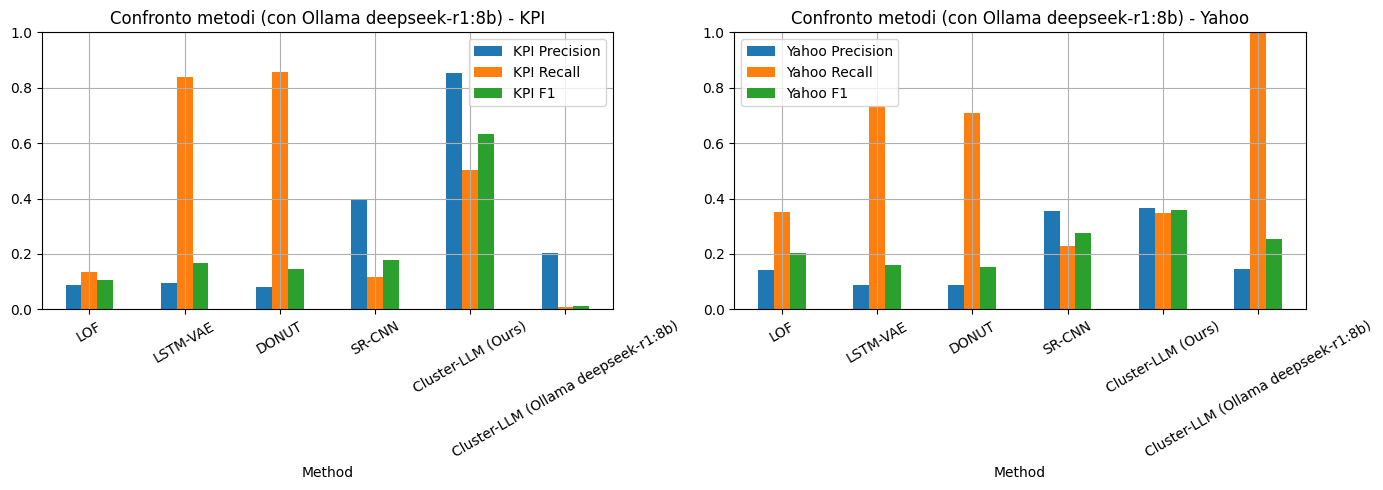

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dataset in zip(axes, ["KPI", "Yahoo"]):
    comparison_table_ollama[[f"{dataset} Precision", f"{dataset} Recall", f"{dataset} F1"]].plot(
        kind="bar", ax=ax, rot=30)
    ax.set_title(f"Confronto metodi (con Ollama deepseek-r1:8b) - {dataset}")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

I due grafici mostrano, per KPI e per Yahoo, le barre di Precision/Recall/F1 di tutti i metodi elencati in `comparison_table_ollama`: permettono di individuare a colpo d'occhio se la riga `Cluster-LLM (Ollama deepseek-r1:8b)` si colloca in linea con `Cluster-LLM (Ours)` (variante deterministica) oppure se se ne discosta significativamente, ad esempio a causa di un numero elevato di fallback verso la logica deterministica o di risposte del LLM non conformi al formato atteso.

### **4. Confronto Diretto: CoT Deterministico (Sezione 7) vs CoT via LLM (Appendice)**

Questo grafico illustra il confronto più rilevante per questa parte: le due varianti di Cluster-LLM a parità di tutto il resto della pipeline (preprocessing, clustering, algoritmo di detection), l'una con CoT deterministico (Sezione 7, sull'intero dataset) e l'altra con CoT realmente inferito dal modello **deepseek-r1:8b** via Ollama (Appendice, sul sottoinsieme `OLLAMA_SUBSAMPLE_N`).

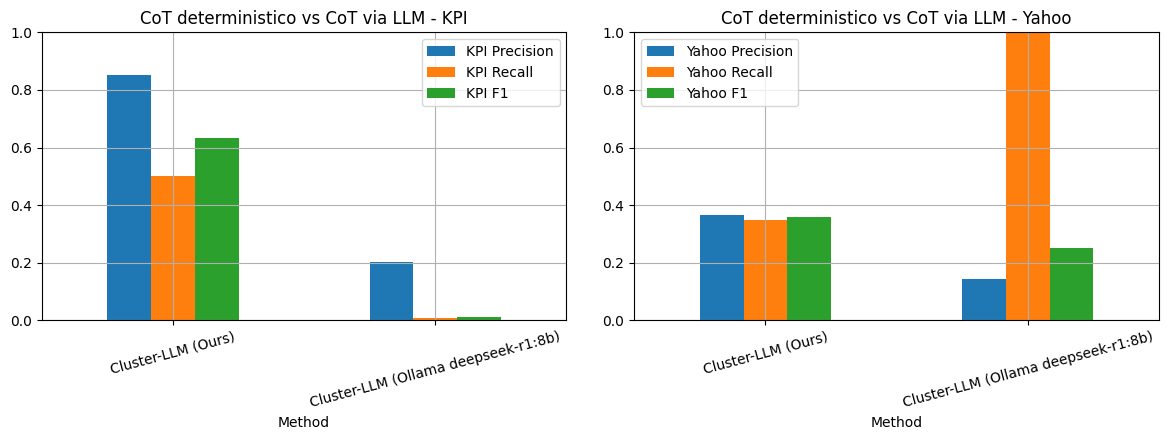

,KPI F1,KPI Precision,KPI Recall,KPI Time(s),Yahoo F1,Yahoo Precision,Yahoo Recall,Yahoo Time(s)
Method,,,,,,,,
Cluster-LLM (Ours),0.632,0.853,0.502,28.9,0.358,0.366,0.349,11.4
Cluster-LLM (Ollama deepseek-r1:8b),0.013,0.202,0.007,29.8,0.252,0.144,1.000,100.3


In [30]:
cot_compare = comparison_table_ollama.loc[
    ["Cluster-LLM (Ours)", "Cluster-LLM (Ollama deepseek-r1:8b)"]
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, dataset in zip(axes, ["KPI", "Yahoo"]):
    cot_compare[[f"{dataset} Precision", f"{dataset} Recall", f"{dataset} F1"]].plot(
        kind="bar", ax=ax, rot=15)
    ax.set_title(f"CoT deterministico vs CoT via LLM - {dataset}")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

cot_compare

Il grafico conferma quindi se, a parità di preprocessing/clustering/detection, sostituire il CoT deterministico con un vero CoT inferito da un LLM locale (`deepseek-r1:8b` via Ollama) mantenga prestazioni comparabili oppure introduca uno scostamento significativo in Precision/Recall/F1: uno scostamento ampio, unito a un numero elevato di fallback in `LLM_CALL_STATS`, è generalmente sintomo di risposte del modello non conformi al formato JSON atteso più che di una reale differenza di qualità della baseline stimata.